# What is GFTM getting wrong on R4, and where else? (Fusion_PhD-38e9.28)

Advisory agent analysis. Every number comes from pyro `pyroscan.nc` / `cube.nc` objects on Pitagora; nothing is read
from a CSV. Background (Fusion_PhD `results/beta_stabilisation_f05/README.md`, 38e9.9): above GS2 β ≈ 0.07 GFTM finds a
compact, even-parity, low-ω KBM on R4 that GS2 does not have; it is B∥-driven, rises with WIDTH and is not converged
in NXGRID.

1. **Numerical settings** on R4 (3 ky × 19 β): max basis (NBASIS 59 / NXGRID 65), FILTER, NMODES, IBRANCH,
   USE_MHD_RULE, velocity resolution (NU/NE). Leaves `GFTM/Runs/scan_beta_f05_diag/R4/*` (GyroRun).
2. **Extents** of every GFTM mode (FILTER 0, NMODES 8) against GS2's mode.
3. **Mode selection and frequency**: the whole unstable GFTM spectrum against GS2, and whether a selection rule finds
   the GS2-like mode.
4. **Other bad cases**: the KBM hypercubes, the β scans and the S1_3 q/ŝ scans, and what the badly-wrong cases share.

GS2 is initial-value: one mode per run, so there is no GS2 subdominant mode to compare against.

In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter
from scipy.integrate import trapezoid
from dotenv import load_dotenv
import pyrokinetics
from pyrokinetics import PyroScan
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.diagnostics import Diagnostics
from pyrokinetics.diagnostics.extent import Extent
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
warnings.filterwarnings("ignore")
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "gftm_r4_diagnosis"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"
plot_dir = ROOT / "Plots" / analysis_name
plot_dir.mkdir(parents=True, exist_ok=True)

case = "R4"
ky_targets = [0.1, 0.2, 0.3]                  # snapped to GS2's grid
beta_high, beta_low = 0.07, 0.05              # GS2 beta numbers: high-beta cells >= 0.07, low-beta control <= 0.05
tol_unconverged = 0.1                         # GS2 growth_rate_tolerance at or above this: unconverged (38e9.9)
fraction = 0.95                               # pyro Extent fraction
gs2_leaf = ("GS2", "scan_beta", "parameter_scan_GS2")
# GFTM leaves on R4: label -> (project, leaf, WIDTH). "base" = FILTER 0.5, NMODES 2, NBASIS 12, NXGRID 32, NU 7, NE 3.
leaves = {
    "base w0.3": ("scan_beta_f05_conv", "width_0p3", 0.3),
    "base w0.8": ("scan_beta_f05", "w0p8", 0.8),
    "base w1.74": ("scan_beta", "parameter_scan_gftm_default", 1.74),   # beta labelled with GS2's numbers (f = 1)
    "nobpar w0.8": ("scan_beta_f05_conv", "nobpar_w0p8", 0.8),
    **{f"maxb w{w:g}": ("scan_beta_f05_diag", f"maxb_w{w:g}".replace(".", "p"), w) for w in (0.3, 0.8, 1.74)},
    **{f"spec w{w:g}": ("scan_beta_f05_diag", f"spec_w{w:g}".replace(".", "p"), w) for w in (0.3, 0.8, 1.74)},
    "spec maxb w0.8": ("scan_beta_f05_diag", "spec_maxb_w0p8", 0.8),
    "ibranch0 w0.8": ("scan_beta_f05_diag", "ibr0_w0p8", 0.8),
    "filter0.7 w0.8": ("scan_beta_f05_diag", "filt0p7_w0p8", 0.8),
    "filter0.9 w0.8": ("scan_beta_f05_diag", "filt0p9_w0p8", 0.8),
    "mhd w0.8": ("scan_beta_f05_diag", "mhd_w0p8", 0.8),
    "mhd nobpar w0.8": ("scan_beta_f05_diag", "mhd_nobpar_w0p8", 0.8),
    **{f"vel w{w:g}": ("scan_beta_f05_diag", f"vel_w{w:g}".replace(".", "p"), w) for w in (0.3, 0.8)},
}
fs_title, fs_label, fs_tick, fs_legend = 16, 16, 14, 12
field_label = {"phi": r"$\phi$", "apar": r"$A_\parallel$", "bpar": r"$B_\parallel$"}

pyrokinetics 0.9.2.dev149+gf119e687


## Load R4: GS2 and every GFTM leaf
Each leaf is a PyroScan with its `pyroscan.nc`; pyro `Extent` (95%) is added per field and mode. GFTM's ky grid is
selected onto GS2's three ky (asserted), and β is matched by index (GFTM stores pyro β = GS2 β × f, asserted constant).

In [2]:
def v(da):
    return np.asarray(getattr(da.data, "magnitude", da.data))


def load_leaf(code, project, leaf):
    d = data_root / code / run_template / project / case / leaf
    s = PyroScan(pyroscan_json=d / "pyroscan.json", load_base_pyro=True)
    s.load_gk_output(netcdf_file=d / "pyroscan.nc")
    Extent(s.gk_output, fraction=fraction)
    out = s.gk_output.data
    for dim in ("bpar", "kx"):   # nobpar leaves scan numerics.bpar = [False]; GFTM writes a length-1 kx
        out = out.squeeze(dim, drop=True) if dim in out.dims else out
    return out


gs2_all = load_leaf(*gs2_leaf)
iky = [int(np.abs(v(gs2_all.ky) - k).argmin()) for k in ky_targets]
G = gs2_all.isel(ky=iky).transpose("ky", "beta", ...)
beta = v(G.beta)
ky = v(G.ky)
tol = v(G.growth_rate_tolerance)
unconv = tol >= tol_unconverged
hi, lo = beta >= beta_high, beta <= beta_low
g_gs2, w_gs2 = v(G.growth_rate), v(G.mode_frequency)

R = {}
for lab, (project, leaf, _) in leaves.items():
    d = load_leaf("GFTM", project, leaf)
    d = d.sel(ky=ky, method="nearest").transpose("ky", "beta", "mode", ...)
    assert np.allclose(v(d.ky), ky, atol=1e-3) and d.beta.size == beta.size, lab
    f = v(d.beta) / beta
    assert np.allclose(f, f[0], rtol=1e-3), (lab, "beta is not GS2 beta x constant")
    R[lab] = d
print("ky", ky.round(3), "| GS2 beta", beta.round(2))
print("modes per leaf:", {lab: int(d.mode.size) for lab, d in R.items()})
print("GS2 unconverged (tol >= 0.1) at beta >= 0.07:", int(unconv[:, hi].sum()), "of", int(hi.sum() * len(ky)))

ky [0.112 0.2   0.3  ] | GS2 beta [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19]
modes per leaf: {'base w0.3': 2, 'base w0.8': 2, 'base w1.74': 2, 'nobpar w0.8': 2, 'maxb w0.3': 2, 'maxb w0.8': 2, 'maxb w1.74': 2, 'spec w0.3': 8, 'spec w0.8': 8, 'spec w1.74': 8, 'spec maxb w0.8': 8, 'ibranch0 w0.8': 2, 'filter0.7 w0.8': 2, 'filter0.9 w0.8': 2, 'mhd w0.8': 2, 'mhd nobpar w0.8': 2, 'vel w0.3': 2, 'vel w0.8': 2}
GS2 unconverged (tol >= 0.1) at beta >= 0.07: 31 of 39


## (1) Numerical settings
Dominant mode = argmax γ over `mode`. GFTM clamps stable cells (no unstable mode) to γ = 0, so they score γ = 0.
Metric: `LogMed |γ_GFTM − γ_GS2|` (log10 of the median absolute error) over the high-β cells (β ≥ 0.07, n = 39)
and over the low-β control (β ≤ 0.05, n = 15), where GS2 is converged and the codes agreed in 38e9.9.

In [3]:
def dominant(d, name):
    m = np.nan_to_num(v(d.growth_rate), nan=-np.inf).argmax(-1)
    return d[name].isel(mode=xr.DataArray(m, dims=("ky", "beta")))


def gamma_dom(d):
    g = v(dominant(d, "growth_rate"))
    return np.where(np.isfinite(g) & (g > 0), g, 0.0)


def logmed(g, mask):
    return float(np.log10(np.median(np.abs(g - g_gs2)[mask])))


g = {lab: gamma_dom(d) for lab, d in R.items()}
w = {lab: v(dominant(d, "mode_frequency")) for lab, d in R.items()}
summary = pd.DataFrame({lab: {"WIDTH": leaves[lab][2], "LogMed hi": logmed(g[lab], hi[None, :] & np.ones((3, 1), bool)),
                              "LogMed lo": logmed(g[lab], lo[None, :] & np.ones((3, 1), bool)),
                              **{f"max g hi ky{k:.2f}": g[lab][i, hi].max() for i, k in enumerate(ky)}}
                        for lab in R}).T
print("GS2 max gamma at beta >= 0.07 per ky:", g_gs2[:, hi].max(1).round(3))
print(summary.round(3).to_string())

GS2 max gamma at beta >= 0.07 per ky: [0.018 0.012 0.005]
                 WIDTH  LogMed hi  LogMed lo  max g hi ky0.11  max g hi ky0.20  max g hi ky0.30
base w0.3         0.30     -1.329     -1.929            0.058            0.125            0.101
base w0.8         0.80     -0.440     -1.705            0.948            0.778            0.325
base w1.74        1.74     -0.170     -0.888            0.975            0.737            0.347
nobpar w0.8       0.80     -1.696     -0.821            0.015            0.021            0.252
maxb w0.3         0.30     -1.682     -2.047            0.019            0.039            0.047
maxb w0.8         0.80     -1.022     -2.046            0.134            0.357            0.285
maxb w1.74        1.74     -0.274     -1.287            1.019            0.880            0.514
spec w0.3         0.30     -1.329     -1.929            0.058            0.125            0.101
spec w0.8         0.80     -0.440     -1.705            0.948            0.778

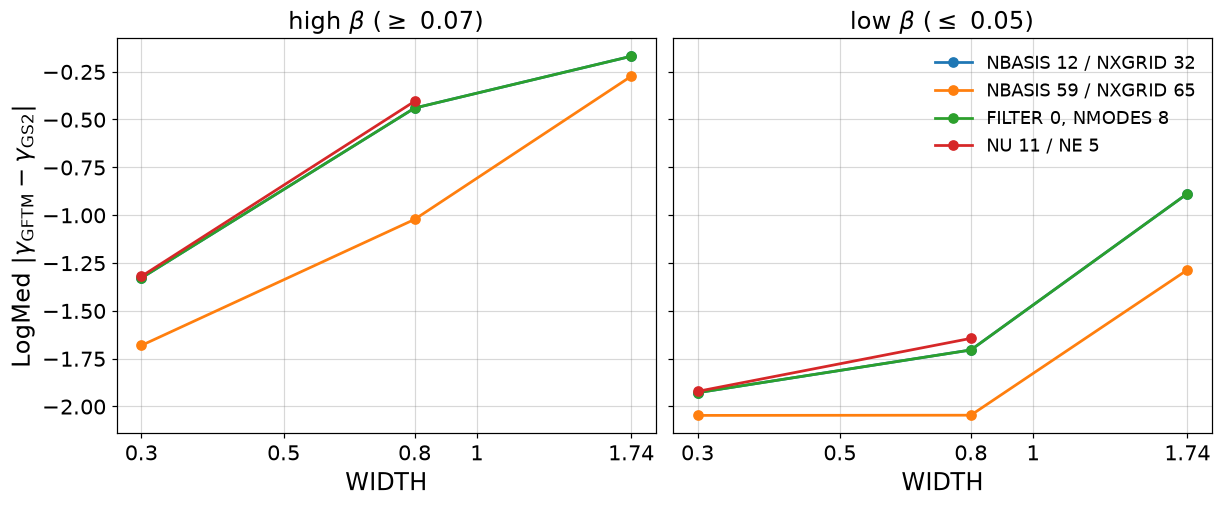

In [4]:
width_sets = {   # line label -> leaf label per WIDTH
    "NBASIS 12 / NXGRID 32": {0.3: "base w0.3", 0.8: "base w0.8", 1.74: "base w1.74"},
    "NBASIS 59 / NXGRID 65": {0.3: "maxb w0.3", 0.8: "maxb w0.8", 1.74: "maxb w1.74"},
    "FILTER 0, NMODES 8": {0.3: "spec w0.3", 0.8: "spec w0.8", 1.74: "spec w1.74"},
    "NU 11 / NE 5": {0.3: "vel w0.3", 0.8: "vel w0.8"},
}
fig_ew, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (col, title) in zip(axes, (("LogMed hi", r"high $\beta$ ($\geq$ 0.07)"), ("LogMed lo", r"low $\beta$ ($\leq$ 0.05)"))):
    for name, ws in width_sets.items():
        ax.plot(list(ws), [summary.loc[lab, col] for lab in ws.values()], label=name)
    ax.set_xscale("log")
    ax.set_xticks([0.3, 0.5, 0.8, 1, 1.74])
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()
    ax.set_title(title, fontsize=fs_title)
    ax.set_xlabel("WIDTH", fontsize=fs_label)
    ax.tick_params(labelsize=fs_tick)
axes[0].set_ylabel(r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$", fontsize=fs_label)
axes[1].legend(fontsize=fs_legend)
fig_ew.savefig(plot_dir / "R4_error_vs_width.png", dpi=150, bbox_inches="tight")
plt.show()

γ and ω against β for every setting, one row per group of settings, one column per ky. GS2 black; open circles are
GS2 cells with tolerance ≥ 0.1.

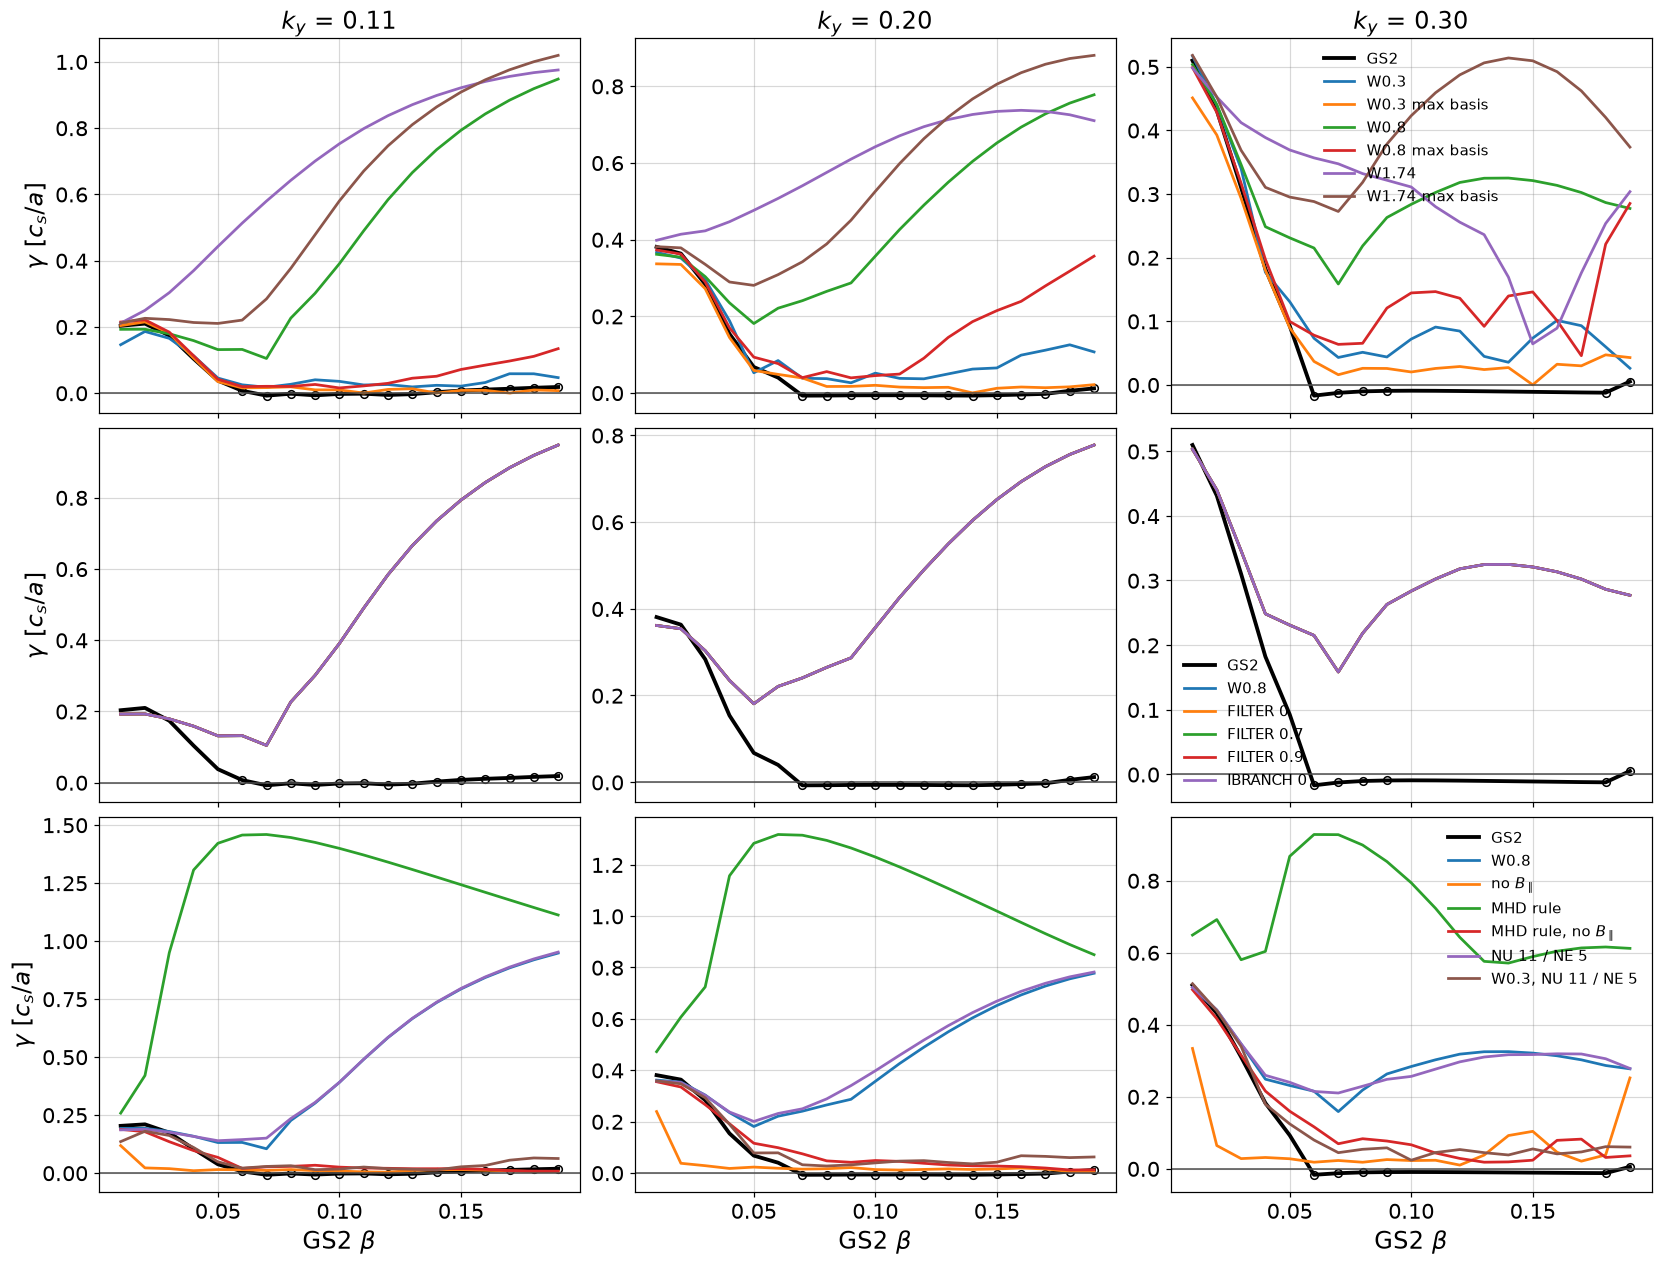

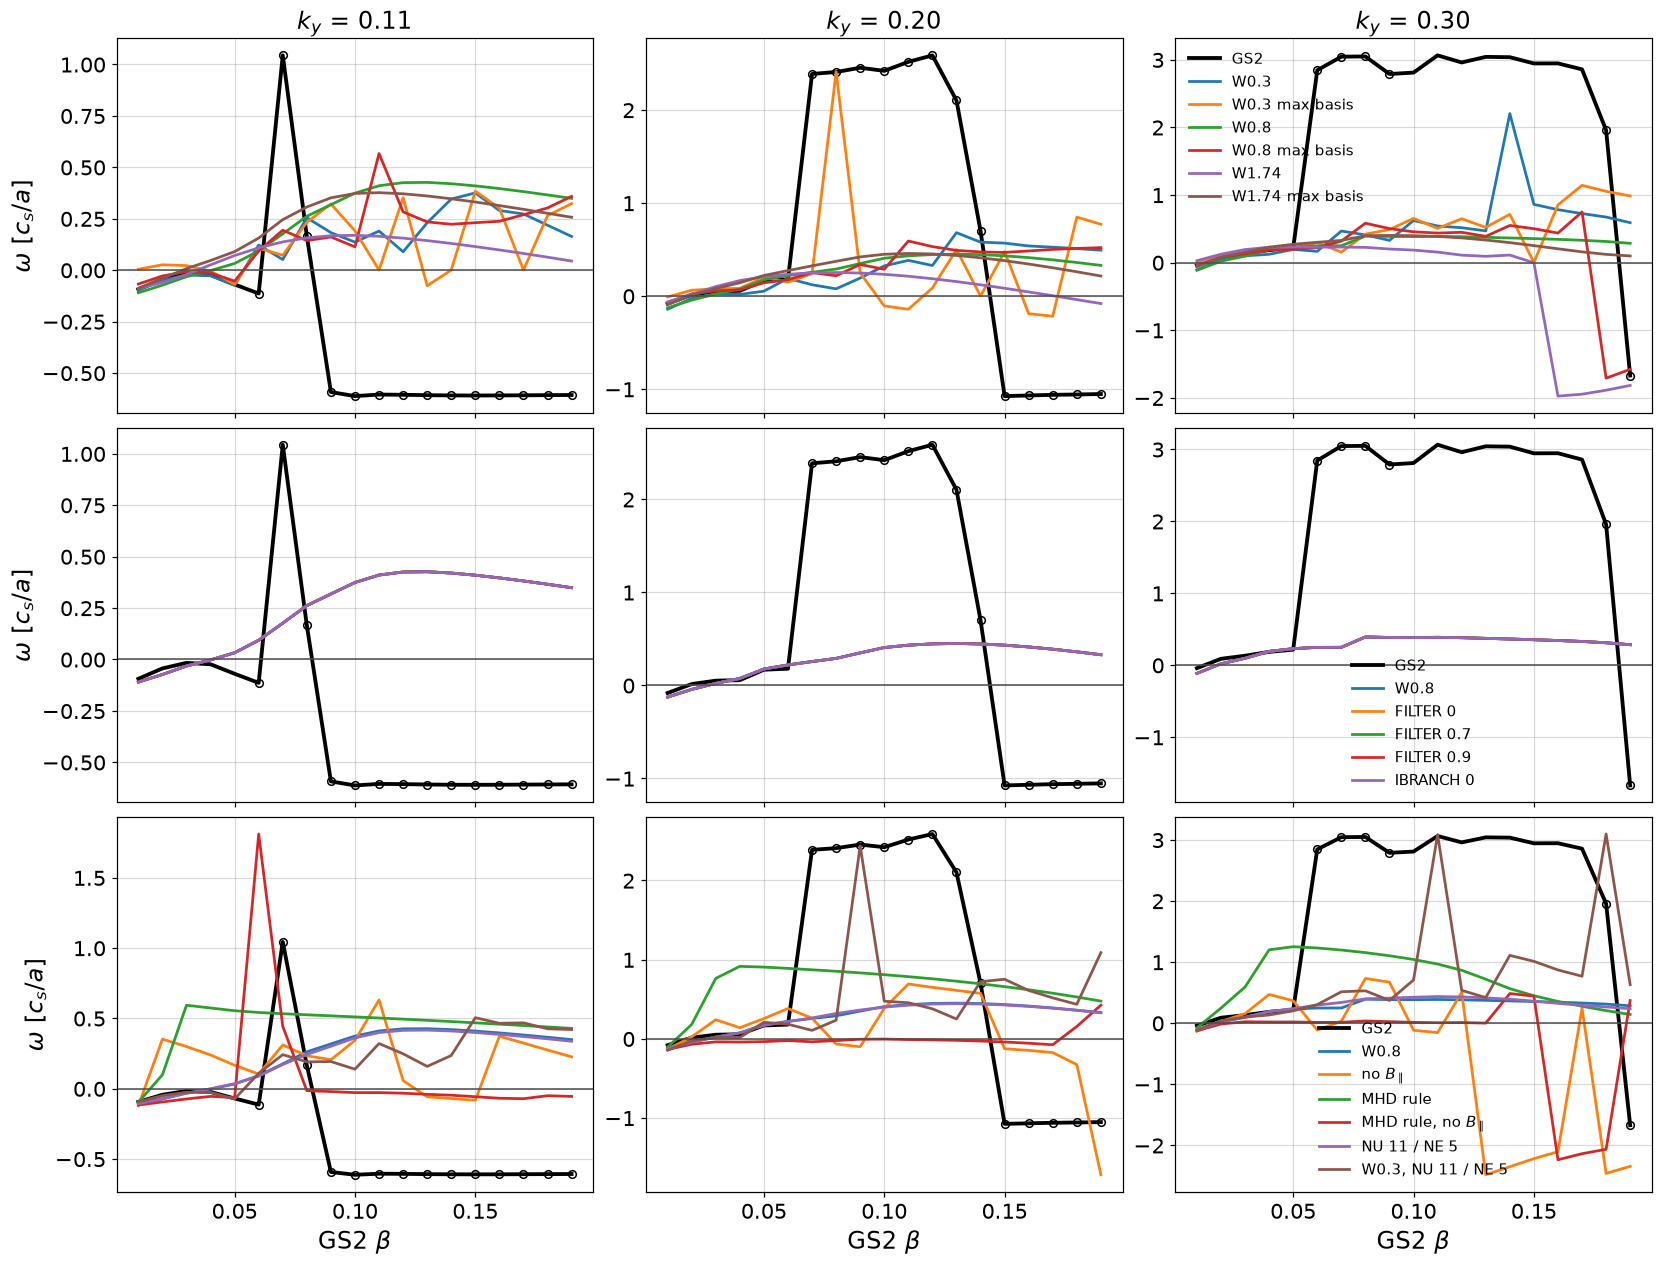

In [5]:
groups = {
    "basis": ["base w0.3", "maxb w0.3", "base w0.8", "maxb w0.8", "base w1.74", "maxb w1.74"],
    "selection": ["base w0.8", "spec w0.8", "filter0.7 w0.8", "filter0.9 w0.8", "ibranch0 w0.8"],
    "physics": ["base w0.8", "nobpar w0.8", "mhd w0.8", "mhd nobpar w0.8", "vel w0.8", "vel w0.3"],
}
short = {"base w0.3": "W0.3", "maxb w0.3": "W0.3 max basis", "base w0.8": "W0.8", "maxb w0.8": "W0.8 max basis",
         "base w1.74": "W1.74", "maxb w1.74": "W1.74 max basis", "spec w0.8": "FILTER 0", "filter0.7 w0.8": "FILTER 0.7",
         "filter0.9 w0.8": "FILTER 0.9", "ibranch0 w0.8": "IBRANCH 0", "nobpar w0.8": r"no $B_\parallel$",
         "mhd w0.8": "MHD rule", "mhd nobpar w0.8": r"MHD rule, no $B_\parallel$", "vel w0.8": "NU 11 / NE 5",
         "vel w0.3": "W0.3, NU 11 / NE 5"}
figs_set = {}
for var, ylab, data, ref in (("gamma", r"$\gamma$ [$c_s/a$]", g, g_gs2), ("omega", r"$\omega$ [$c_s/a$]", w, w_gs2)):
    fig, axes = plt.subplots(len(groups), len(ky), figsize=(5 * len(ky), 3.8 * len(groups)), sharex=True)
    for row, (grp, labs) in enumerate(groups.items()):
        for col in range(len(ky)):
            ax = axes[row, col]
            ax.plot(beta, ref[col], color="k", lw=2.5, label="GS2", marker="none")
            ax.plot(beta[unconv[col]], ref[col, unconv[col]], color="k", ls="", marker="o", ms=5, mfc="none")
            for n, lab in enumerate(labs):
                ax.plot(beta, data[lab][col], color=f"C{n}", label=short[lab], marker="none")
            ax.axhline(0, color="0.3", lw=1, marker="")
            ax.tick_params(labelsize=fs_tick)
            if row == 0:
                ax.set_title(rf"$k_y$ = {ky[col]:.2f}", fontsize=fs_title)
        axes[row, 0].set_ylabel(ylab, fontsize=fs_label)
        axes[row, -1].legend(fontsize=10)
    for ax in axes[-1]:
        ax.set_xlabel(r"GS2 $\beta$", fontsize=fs_label)
    fig.savefig(plot_dir / f"R4_settings_{var}_vs_beta.png", dpi=150, bbox_inches="tight")
    figs_set[var] = fig
plt.show()

### Settings audit
What each leaf ran is in its `pyroscan.json` (requested) and per run in `input.gftm.gen` / `out.gftm.localdump`
(used); the count audit is Fusion_PhD `tools/pitagora_scans/gyrorun_leaf_audit.py` (its result is in the Fusion_PhD
README). Here: IBRANCH 0 returns the most unstable mode of each frequency sign in fixed slots.

In [6]:
d = R["ibranch0 w0.8"]
wi = v(d.mode_frequency)
for m in range(d.mode.size):
    ok = np.isfinite(wi[..., m]) & (v(d.growth_rate)[..., m] > 0)
    print(f"IBRANCH 0, mode slot {m}: unstable in {ok.sum()} of {ok.size} cells, omega sign +{(wi[..., m][ok] > 0).sum()} / "
          f"-{(wi[..., m][ok] < 0).sum()}")

IBRANCH 0, mode slot 0: unstable in 57 of 57 cells, omega sign +0 / -57
IBRANCH 0, mode slot 1: unstable in 57 of 57 cells, omega sign +57 / -0


## (2) and (3) The whole GFTM spectrum against GS2
FILTER 0 / NMODES 8: GFTM returns up to 8 unstable modes per cell (`sort_eigenvalues` keeps only γ > 0, so stable
modes are never output). Each mode is typed by the T + ω rule of `docs/mode_filtering.md` (KBM: T < 0.05 and ω > 0;
MTM: T > 0.15 and ω < 0; else mixed); T is the stored `tearing_parameter`.

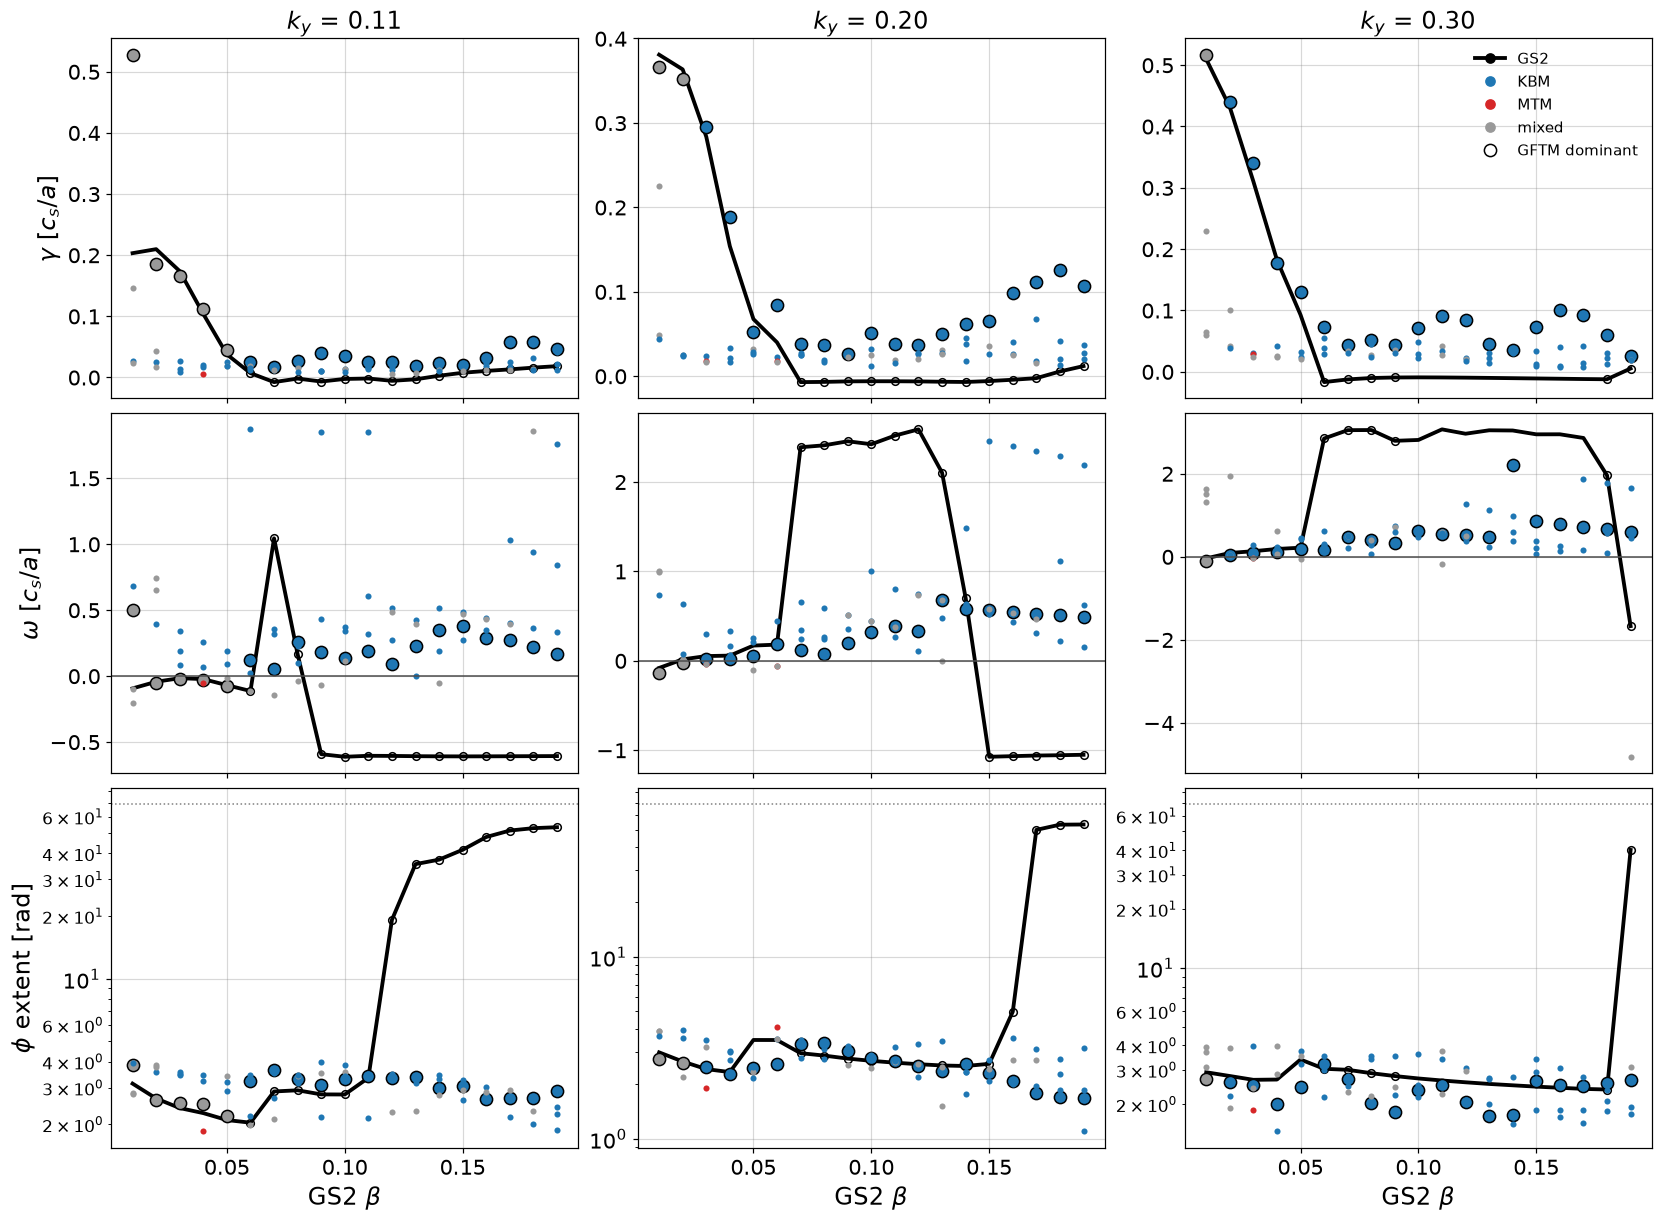

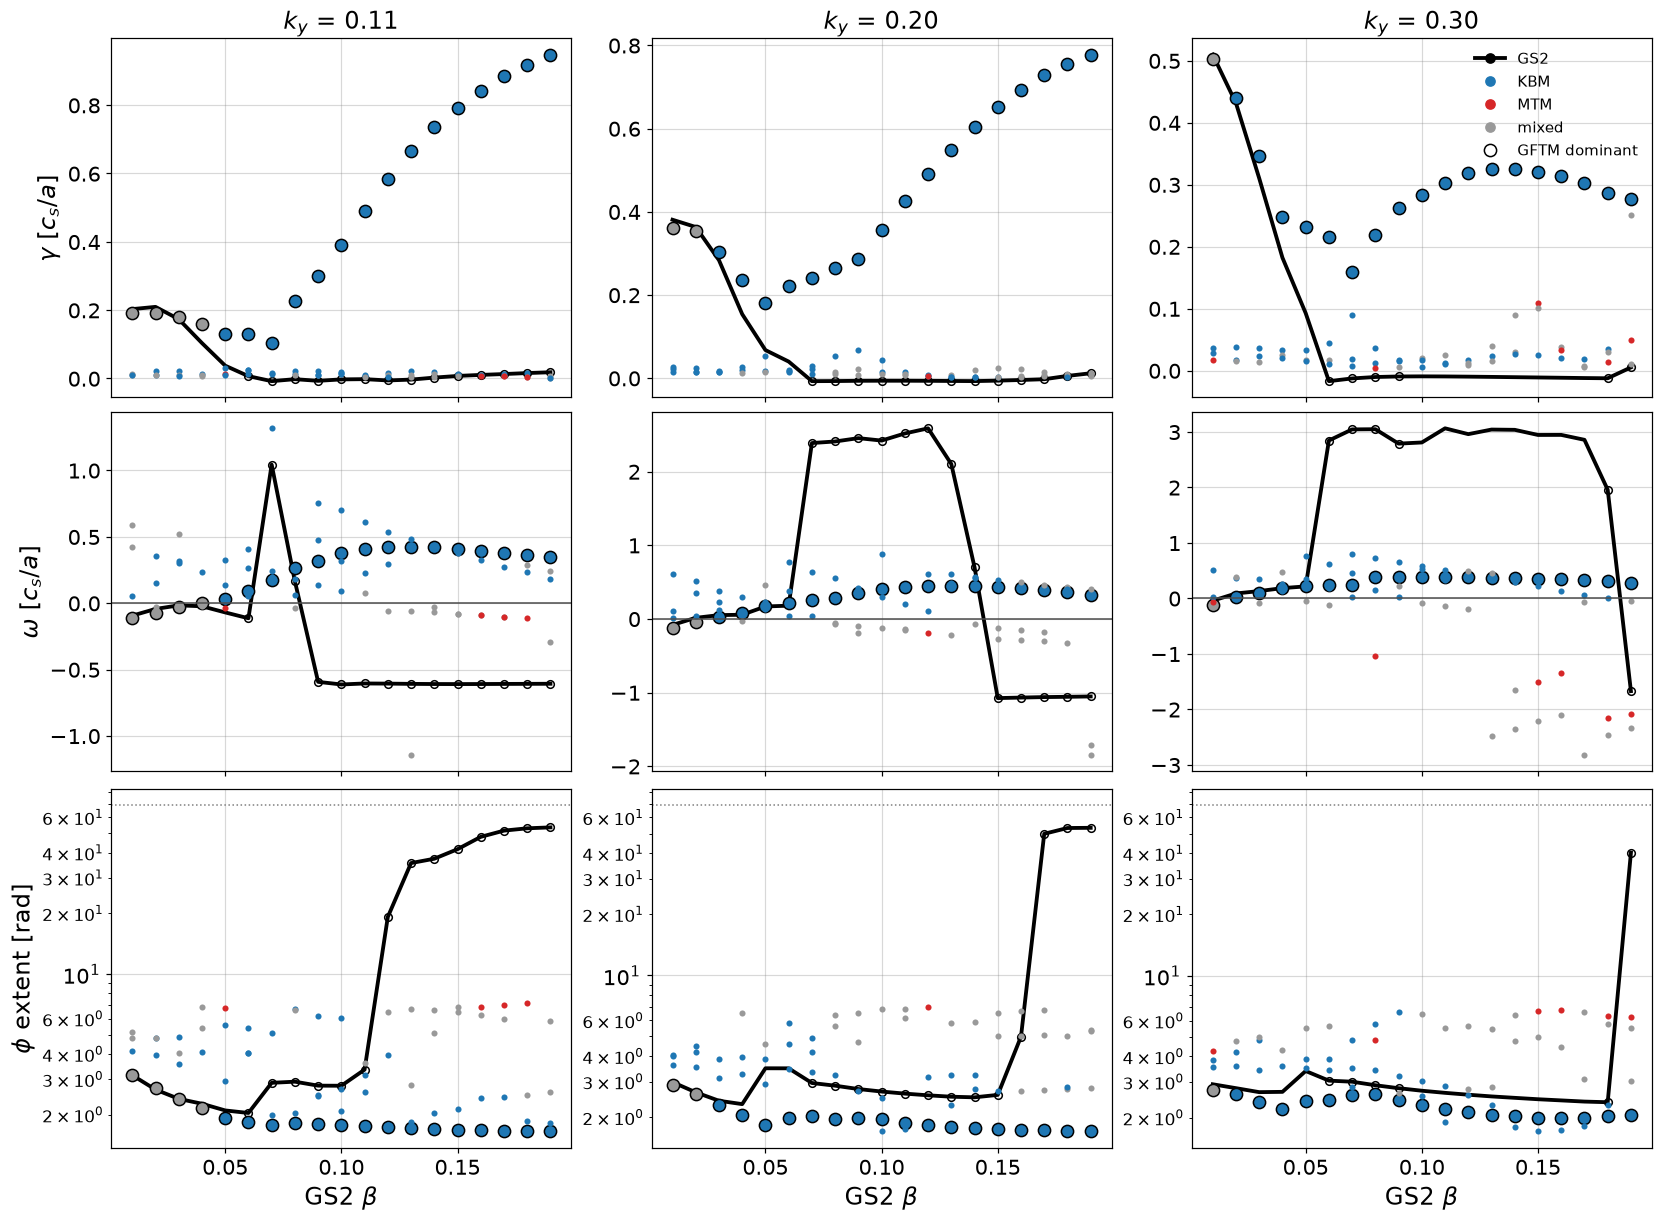

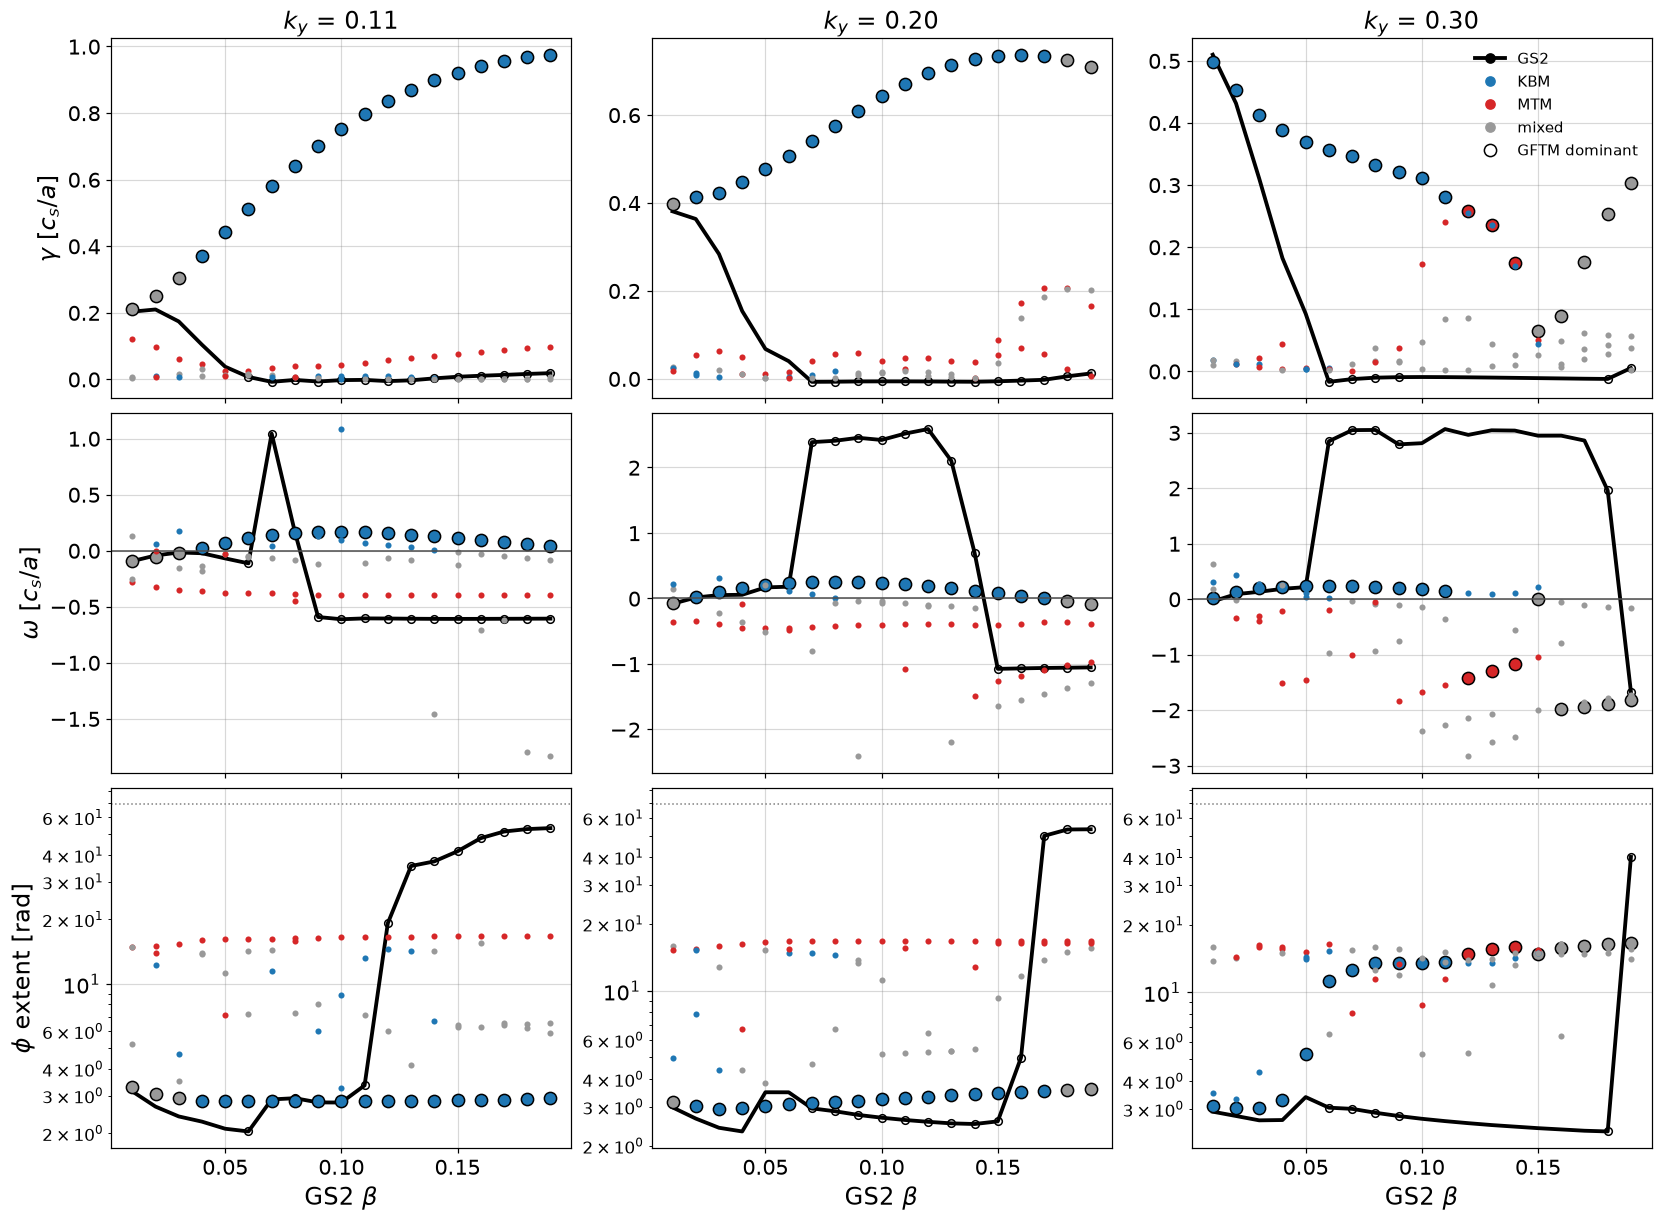

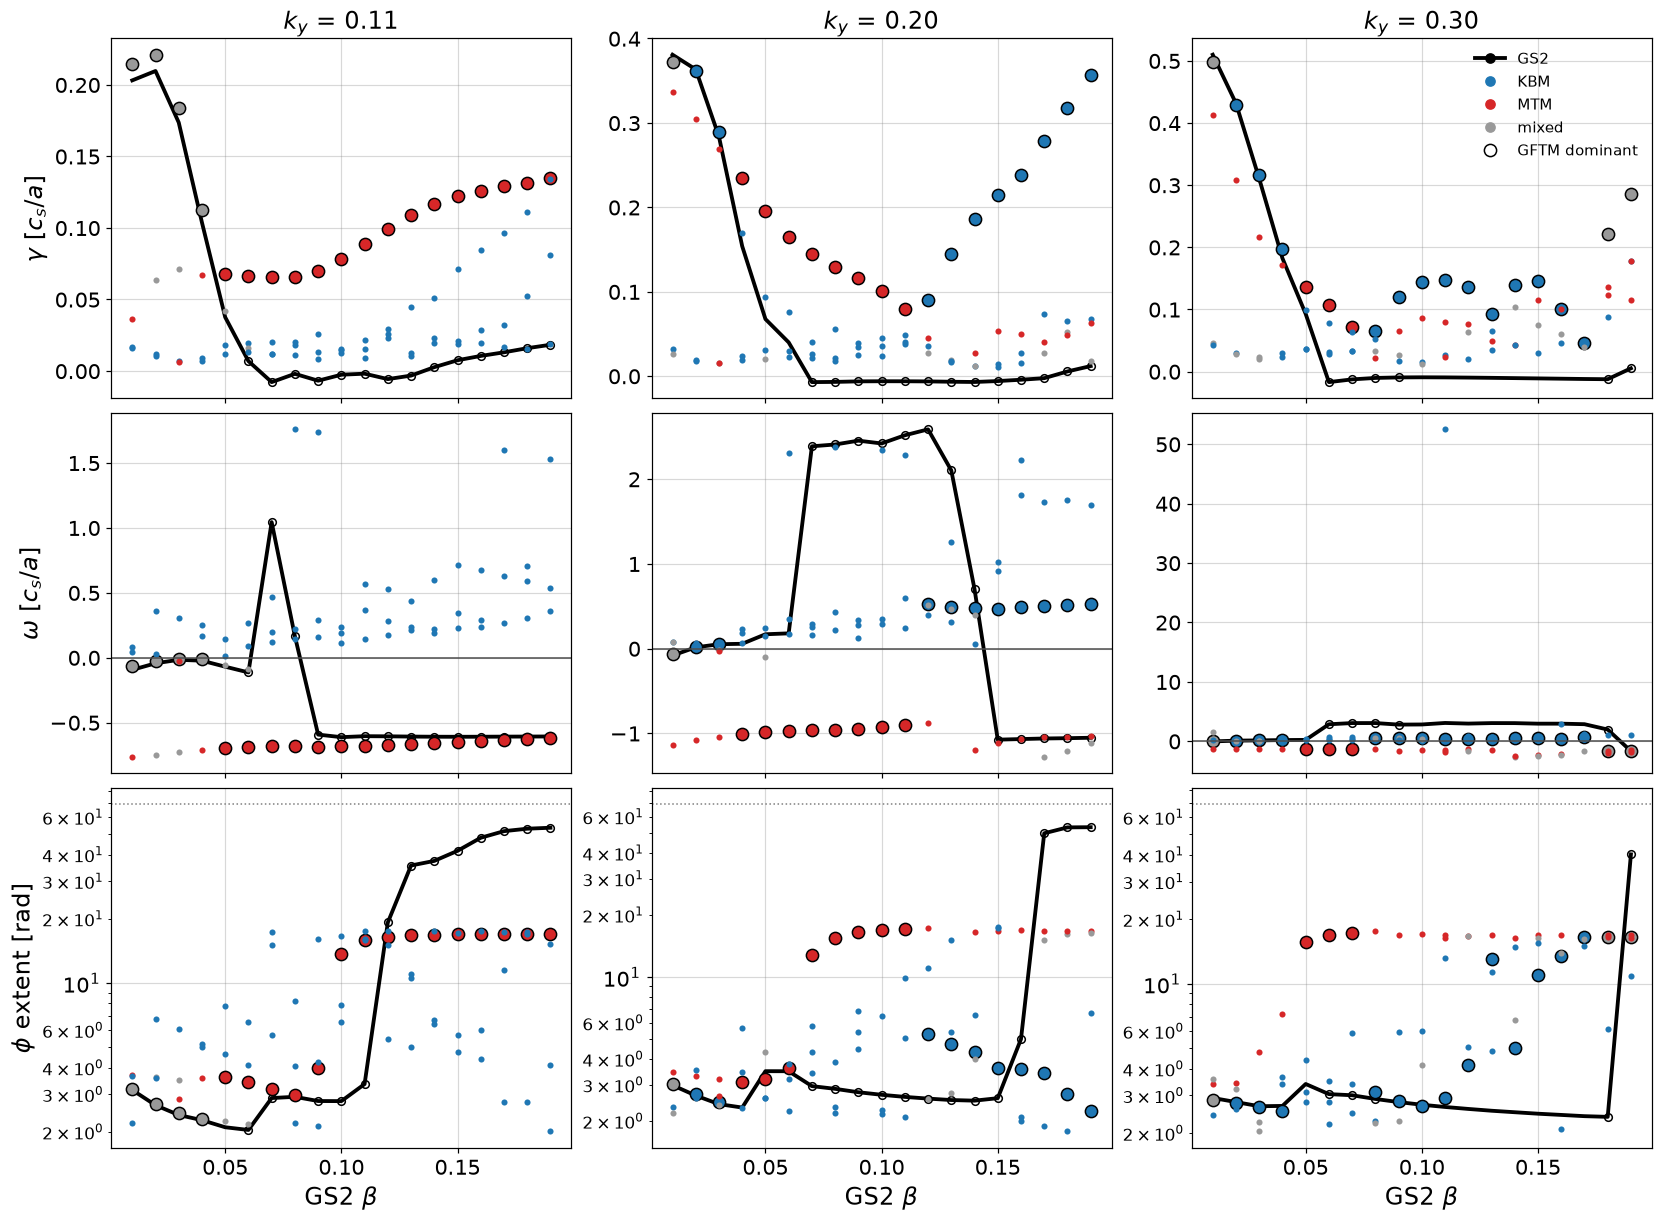

spec w0.3: unstable modes per high-beta cell: median 4, max 4
   KBM   n 129: omega +0.10..+1.87, gamma max 0.125, phi extent 1.7..3.5
   mixed n  27: omega -0.16..+0.73, gamma max 0.041, phi extent 2.1..3.5
spec w0.8: unstable modes per high-beta cell: median 4, max 4
   KBM   n  95: omega +0.06..+0.71, gamma max 0.948, phi extent 1.7..5.3
   MTM   n   9: omega -2.13..-0.10, gamma max 0.109, phi extent 5.4..7.1
   mixed n  52: omega -2.40..+0.46, gamma max 0.251, phi extent 2.7..6.8
spec w1.74: unstable modes per high-beta cell: median 4, max 4
   KBM   n  43: omega +0.01..+0.25, gamma max 0.975, phi extent 2.8..14.6
   MTM   n  43: omega -1.53..-0.37, gamma max 0.257, phi extent 11.4..16.8
   mixed n  69: omega -2.40..-0.04, gamma max 0.725, phi extent 4.9..16.2
spec maxb w0.8: unstable modes per high-beta cell: median 4, max 4
   KBM   n 100: omega +0.14..+2.23, gamma max 0.357, phi extent 2.1..17.4
   MTM   n  40: omega -2.16..-0.63, gamma max 0.178, phi extent 3.9..17.3
   mixed n

In [7]:
spec_leaves = ["spec w0.3", "spec w0.8", "spec w1.74", "spec maxb w0.8"]
type_colour = {"KBM": "C0", "MTM": "C3", "mixed": "0.6"}
box = float(np.ptp(v(G.theta)))
ext_gs2 = v(G.extent.sel(field="phi"))


def mode_types(d):
    return mc.classify_T_omega({"T": v(d.tearing_parameter), "omega": mc.ION_DIRECTION * v(d.mode_frequency)})


figs_spec = {}
for lab in spec_leaves:
    d = R[lab]
    gm, wm, em = v(d.growth_rate), v(d.mode_frequency), v(d.extent.sel(field="phi"))
    typ, dm = mode_types(d), np.nan_to_num(gm, nan=-np.inf).argmax(-1)
    fig, axes = plt.subplots(3, len(ky), figsize=(5 * len(ky), 11), sharex=True)
    for col in range(len(ky)):
        for row, (y, ref) in enumerate(((gm, g_gs2), (wm, w_gs2), (em, ext_gs2))):
            ax = axes[row, col]
            ax.plot(beta, ref[col], color="k", lw=2.5, marker="none")
            ax.plot(beta[unconv[col]], ref[col, unconv[col]], color="k", ls="", marker="o", ms=5, mfc="none")
            for j in range(beta.size):
                for m in range(d.mode.size):
                    if np.isfinite(gm[col, j, m]) and gm[col, j, m] > 0:
                        big = m == dm[col, j]
                        ax.plot(beta[j], y[col, j, m], ls="", marker="o", ms=8 if big else 4, color=type_colour[typ[col, j, m]],
                                mec="k" if big else "none")
            ax.tick_params(labelsize=fs_tick)
        axes[1, col].axhline(0, color="0.3", lw=1, marker="")
        axes[2, col].axhline(box, color="0.5", ls=":", lw=1, marker="")
        axes[2, col].set_yscale("log")
        axes[0, col].set_title(rf"$k_y$ = {ky[col]:.2f}", fontsize=fs_title)
        axes[-1, col].set_xlabel(r"GS2 $\beta$", fontsize=fs_label)
    for row, yl in enumerate((r"$\gamma$ [$c_s/a$]", r"$\omega$ [$c_s/a$]", r"$\phi$ extent [rad]")):
        axes[row, 0].set_ylabel(yl, fontsize=fs_label)
    axes[0, -1].legend(handles=[Line2D([], [], color="k", lw=2.5, label="GS2"),
                                *[Line2D([], [], color=c, ls="", marker="o", label=t) for t, c in type_colour.items()],
                                Line2D([], [], color="w", mec="k", ls="", marker="o", ms=8, label="GFTM dominant")], fontsize=10)
    fig.savefig(plot_dir / f"R4_spectrum_{lab.replace(' ', '_').replace('.', 'p')}.png", dpi=150, bbox_inches="tight")
    figs_spec[lab] = fig
plt.show()

for lab in spec_leaves:
    d = R[lab]
    gm, wm, em = v(d.growth_rate), v(d.mode_frequency), v(d.extent.sel(field="phi"))
    typ = mode_types(d)
    ok = np.isfinite(gm) & (gm > 0) & hi[None, :, None]
    n = ok.sum((0, 1))
    print(f"{lab}: unstable modes per high-beta cell: median {np.median(ok.sum(-1)):.0f}, max {ok.sum(-1).max()}")
    for t in type_colour:
        s = ok & (typ == t)
        if s.any():
            print(f"   {t:5s} n {s.sum():3d}: omega {np.percentile(wm[s], 5):+.2f}..{np.percentile(wm[s], 95):+.2f}, "
                  f"gamma max {gm[s].max():.3f}, phi extent {np.percentile(em[s], 5):.1f}..{np.percentile(em[s], 95):.1f}")
print("GS2 high-beta cells: omega", np.nanmin(w_gs2[:, hi]).round(2), "..", np.nanmax(w_gs2[:, hi]).round(2),
      "| phi extent", np.nanmin(ext_gs2[:, hi]).round(1), "..", np.nanmax(ext_gs2[:, hi]).round(1))
print("GS2 low-beta cells:  omega", np.nanmin(w_gs2[:, lo]).round(2), "..", np.nanmax(w_gs2[:, lo]).round(2),
      "| phi extent", np.nanmin(ext_gs2[:, lo]).round(1), "..", np.nanmax(ext_gs2[:, lo]).round(1))

### Is a GS2-like mode in GFTM's spectrum? (oracle, a containment measure)
Two oracles over the unstable GFTM modes of each cell: **overlap**, the mode with the largest normalised
|⟨φ_GFTM, φ_GS2⟩| (GFTM interpolated onto GS2's θ grid, zero outside its ±9π plot range, maximised over complex
conjugation, as `gftm_bpar_ratio`), and **eigenvalue**, the mode nearest GS2 in (γ, ω). These consult GS2, so they say
whether the right mode is *present*, not whether GFTM would pick it. At β ≥ 0.07 GS2's own eigenfunction is
unconverged (38e9.9 finding 4), so the overlap there is qualitative.

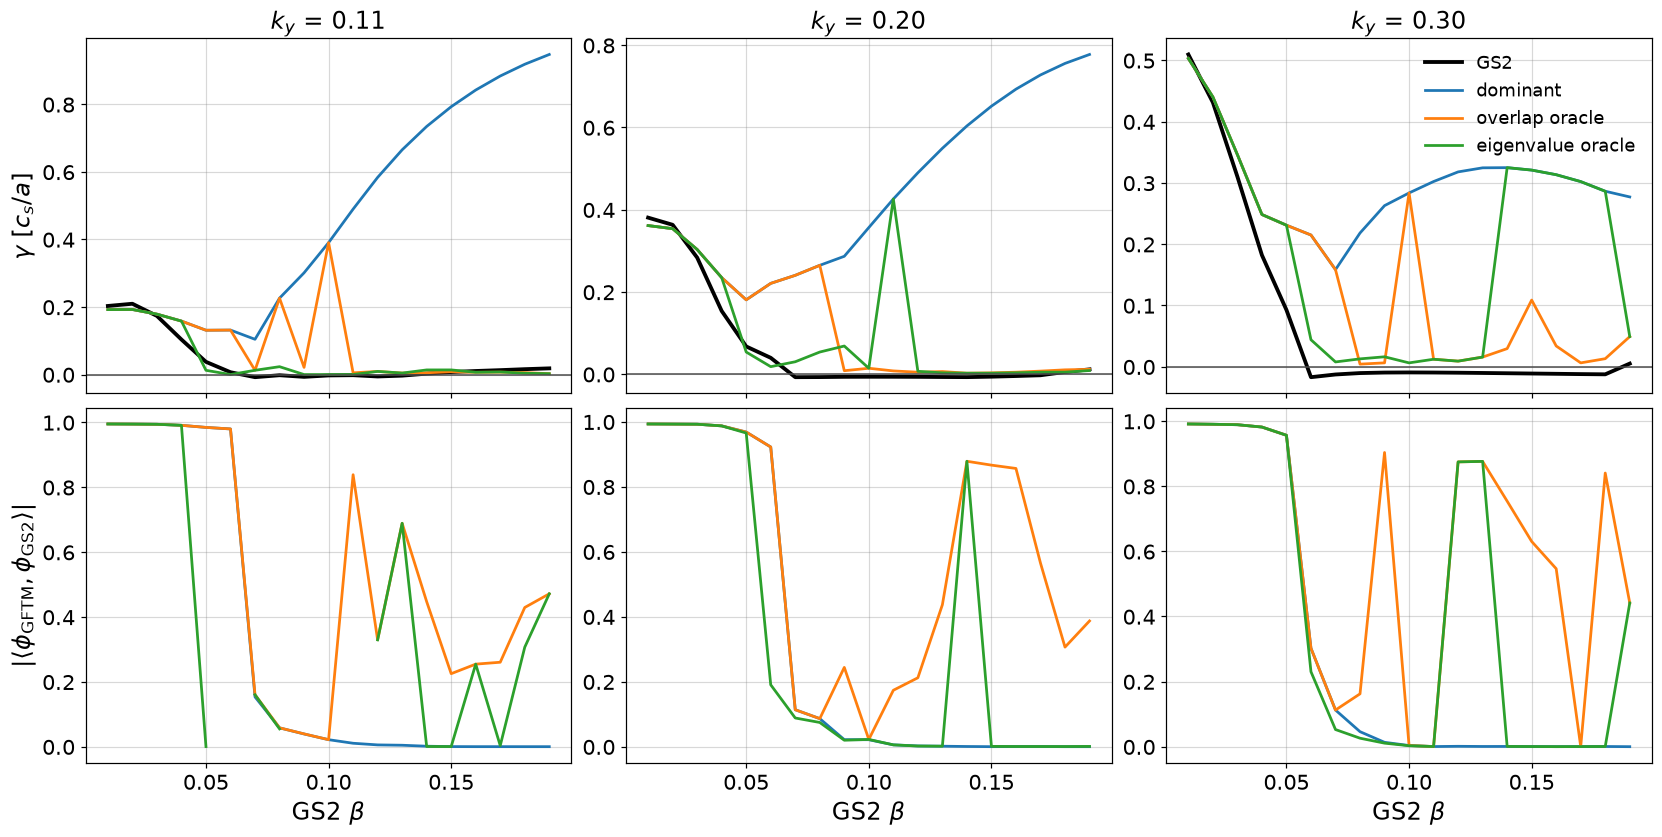

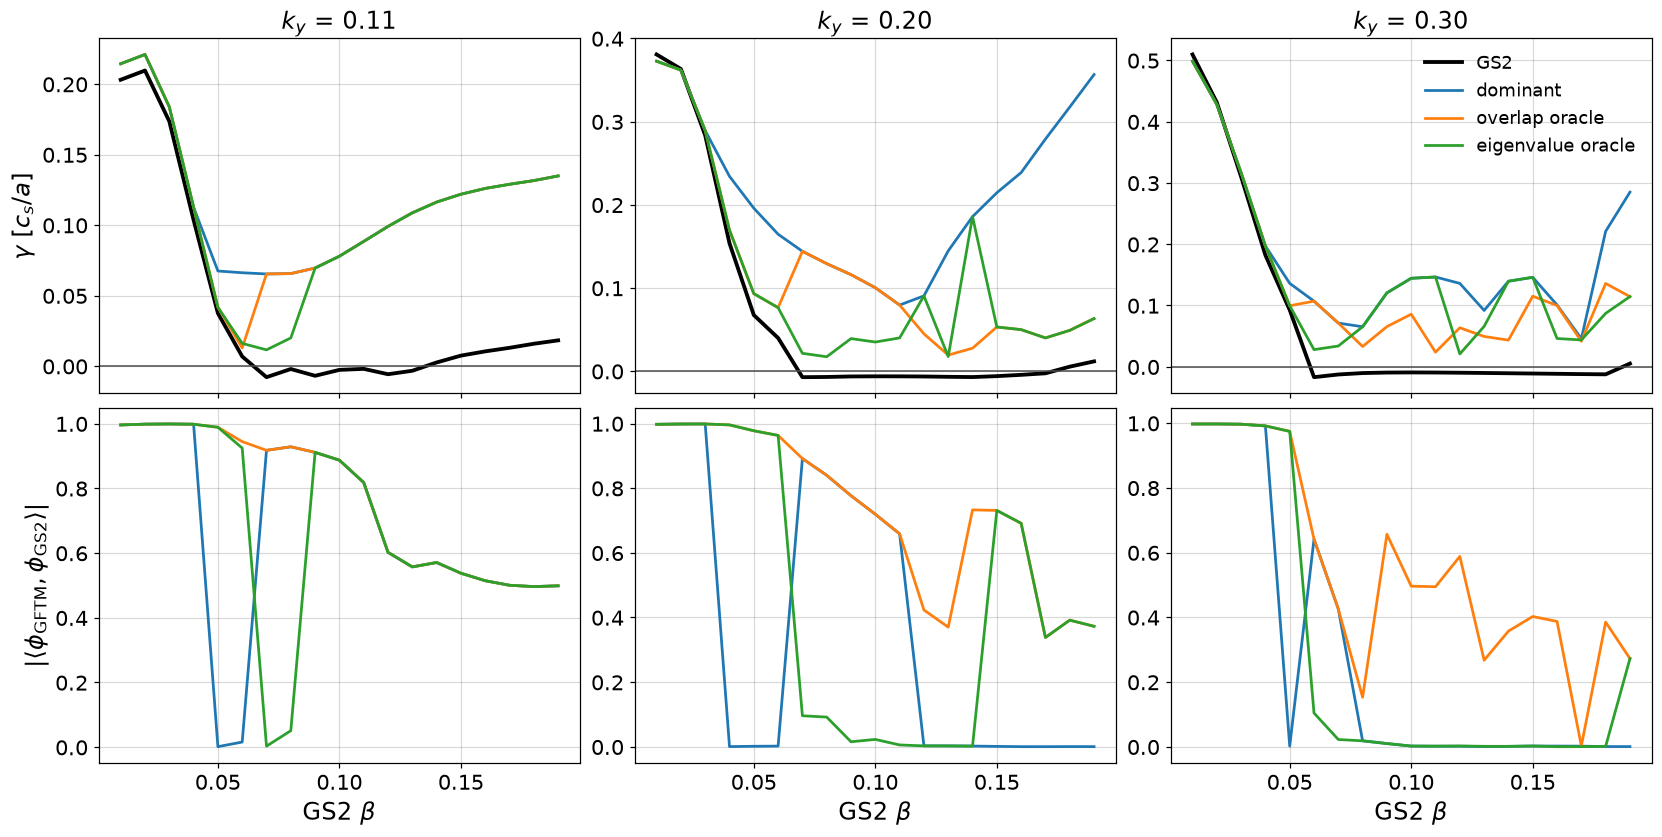

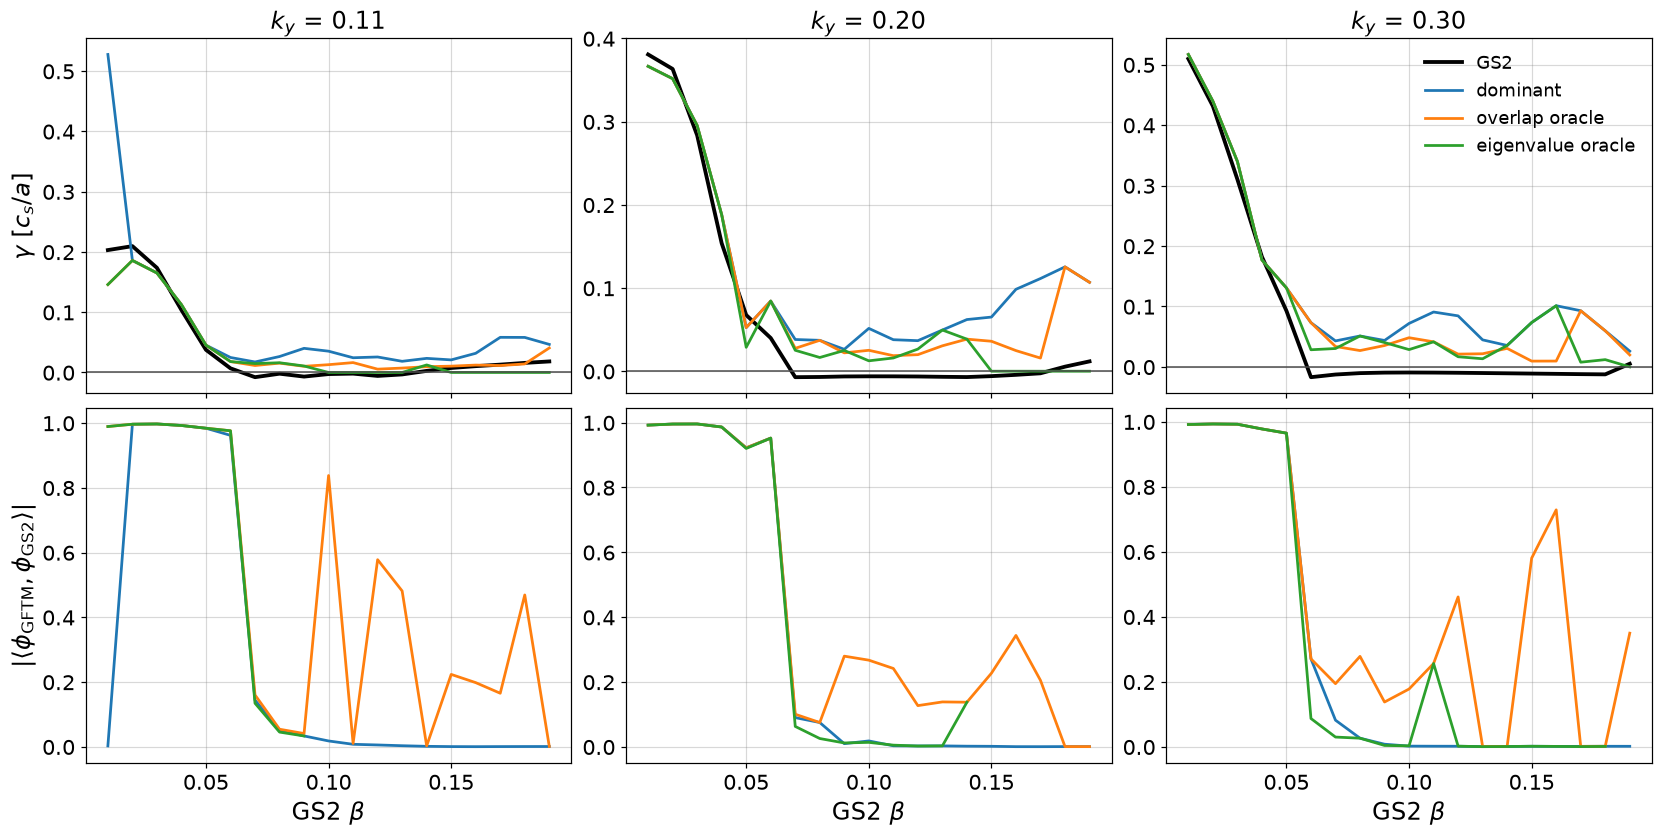

spec w0.3       high beta: dominant = overlap oracle in 5/39; median overlap dominant 0.00, oracle 0.18
spec w0.3       low beta: dominant = overlap oracle in 14/15; median overlap dominant 0.99, oracle 0.99
spec w0.8       high beta: dominant = overlap oracle in 6/39; median overlap dominant 0.00, oracle 0.33
spec w0.8       low beta: dominant = overlap oracle in 15/15; median overlap dominant 0.99, oracle 0.99
spec w1.74      high beta: dominant = overlap oracle in 6/39; median overlap dominant 0.00, oracle 0.32
spec w1.74      low beta: dominant = overlap oracle in 12/15; median overlap dominant 0.97, oracle 0.97
spec maxb w0.8  high beta: dominant = overlap oracle in 19/39; median overlap dominant 0.02, oracle 0.51
spec maxb w0.8  low beta: dominant = overlap oracle in 11/15; median overlap dominant 1.00, oracle 1.00


In [8]:
def overlap(phi_s, th_s, phi_g, th_g):
    pg = np.interp(th_s, th_g, phi_g.real, left=0, right=0) + 1j * np.interp(th_s, th_g, phi_g.imag, left=0, right=0)
    ip = lambda a, b: abs(trapezoid(np.conj(a) * b, th_s))
    return max(ip(pg, phi_s), ip(np.conj(pg), phi_s)) / np.sqrt(ip(pg, pg) * ip(phi_s, phi_s))


th_s, phi_s = v(G.theta), v(G.eigenfunctions.sel(field="phi"))   # (ky, beta, theta)
O, pick = {}, {}
for lab in spec_leaves:
    d = R[lab]
    gm, wm = v(d.growth_rate), v(d.mode_frequency)
    th_g, phi_g = v(d.theta), v(d.eigenfunctions.sel(field="phi").transpose("ky", "beta", "mode", "theta"))
    o = np.full(gm.shape, np.nan)
    for i, j, m in np.argwhere(np.isfinite(gm) & (gm > 0)):
        ok = np.isfinite(phi_s[i, j])
        o[i, j, m] = overlap(phi_s[i, j][ok], th_s[ok], np.nan_to_num(phi_g[i, j, m]), th_g)
    dist = np.hypot(gm - g_gs2[..., None], wm - w_gs2[..., None])
    O[lab] = o
    pick[lab] = {"dominant": np.nan_to_num(gm, nan=-np.inf).argmax(-1),
                 "overlap oracle": np.nan_to_num(o, nan=-np.inf).argmax(-1),
                 "eigenvalue oracle": np.nan_to_num(dist, nan=np.inf).argmin(-1)}


def take(a, m):
    return np.take_along_axis(a, m[..., None], -1)[..., 0]


figs_or = {}
for lab in ("spec w0.8", "spec maxb w0.8", "spec w0.3"):
    gm = np.nan_to_num(v(R[lab].growth_rate), nan=0.0)
    fig, axes = plt.subplots(2, len(ky), figsize=(5 * len(ky), 7.5), sharex=True)
    for col in range(len(ky)):
        axes[0, col].plot(beta, g_gs2[col], color="k", lw=2.5, label="GS2", marker="none")
        for n, (name, m) in enumerate(pick[lab].items()):
            axes[0, col].plot(beta, take(gm, m)[col], color=f"C{n}", label=name, marker="none")
            axes[1, col].plot(beta, take(O[lab], m)[col], color=f"C{n}", label=name, marker="none")
        axes[0, col].axhline(0, color="0.3", lw=1, marker="")
        axes[0, col].set_title(rf"$k_y$ = {ky[col]:.2f}", fontsize=fs_title)
        axes[1, col].set_xlabel(r"GS2 $\beta$", fontsize=fs_label)
        for ax in axes[:, col]:
            ax.tick_params(labelsize=fs_tick)
    axes[0, 0].set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=fs_label)
    axes[1, 0].set_ylabel(r"$|\langle\phi_{\rm GFTM},\phi_{\rm GS2}\rangle|$", fontsize=fs_label)
    axes[0, -1].legend(fontsize=fs_legend)
    fig.savefig(plot_dir / f"R4_oracle_{lab.replace(' ', '_').replace('.', 'p')}.png", dpi=150, bbox_inches="tight")
    figs_or[lab] = fig
plt.show()

for lab in spec_leaves:
    o, p = O[lab], pick[lab]
    od, oo = take(o, p["dominant"]), take(o, p["overlap oracle"])
    same = p["dominant"] == p["overlap oracle"]
    for name, mask in (("high beta", hi), ("low beta", lo)):
        mk = np.broadcast_to(mask, od.shape) & np.isfinite(od)
        print(f"{lab:15s} {name}: dominant = overlap oracle in {same[mk].sum()}/{mk.sum()}; median overlap dominant "
              f"{np.median(od[mk]):.2f}, oracle {np.median(oo[mk]):.2f}")

### Would a selection rule pick the GS2-like mode?
Each rule takes the most unstable mode satisfying it, and γ = 0 if none does (which is what GS2 has at high β). Rules:
`KBM` and `MTM` are the T + ω rule; `electron` is ω < 0; `high-ω` is |ω| > 1 c_s/a (GS2's compact damped mode at
ky 0.2-0.3 has ω ≈ 2.4-3, GFTM's spurious KBM ω ≈ 0.3-0.5; the cut is in-sample); `extended` is φ extent > 2π.
Scored as above (LogMed |Δγ| on the high-β and low-β cells), next to the dominant-mode arm.

In [9]:
omega_cut, extent_cut = 1.0, 2 * np.pi
rows = []
for lab in spec_leaves:
    d = R[lab]
    gm, wm, em = v(d.growth_rate), v(d.mode_frequency), v(d.extent.sel(field="phi"))
    typ, unstable = mode_types(d), np.isfinite(gm) & (gm > 0)
    rules = {"dominant": unstable, "KBM": unstable & (typ == "KBM"), "MTM": unstable & (typ == "MTM"),
             "electron": unstable & (mc.ION_DIRECTION * wm < 0), "high-omega": unstable & (np.abs(wm) > omega_cut),
             "extended": unstable & (em > extent_cut)}
    for name, ok in rules.items():
        gr = np.where(ok, gm, -np.inf)
        m = gr.argmax(-1)
        gsel = np.where(ok.any(-1), take(gm, m), 0.0)
        oracle = (m == pick[lab]["overlap oracle"]) & ok.any(-1)
        rows.append({"leaf": lab, "rule": name, "LogMed hi": logmed(gsel, np.broadcast_to(hi, gsel.shape)),
                     "LogMed lo": logmed(gsel, np.broadcast_to(lo, gsel.shape)),
                     "found hi": int(ok.any(-1)[:, hi].sum()), "found lo": int(ok.any(-1)[:, lo].sum()),
                     "= overlap oracle hi": int(oracle[:, hi].sum())})
rules_table = pd.DataFrame(rows)
print(f"cells: high beta {hi.sum() * len(ky)}, low beta {lo.sum() * len(ky)}")
print(rules_table.round(2).to_string(index=False))

cells: high beta 39, low beta 15
          leaf       rule  LogMed hi  LogMed lo  found hi  found lo  = overlap oracle hi
     spec w0.3   dominant      -1.33      -1.93        39        15                    5
     spec w0.3        KBM      -1.33      -1.42        39        14                    5
     spec w0.3        MTM      -2.14      -0.69         0         3                    0
     spec w0.3   electron      -2.01      -1.45         7        12                    3
     spec w0.3 high-omega      -1.99      -0.74        18         3                    4
     spec w0.3   extended      -2.14      -0.69         0         0                    0
     spec w0.8   dominant      -0.44      -1.71        39        15                    6
     spec w0.8        KBM      -0.44      -0.95        39        15                    6
     spec w0.8        MTM      -2.14      -0.69         9         2                    8
     spec w0.8   electron      -1.83      -1.26        32        11          

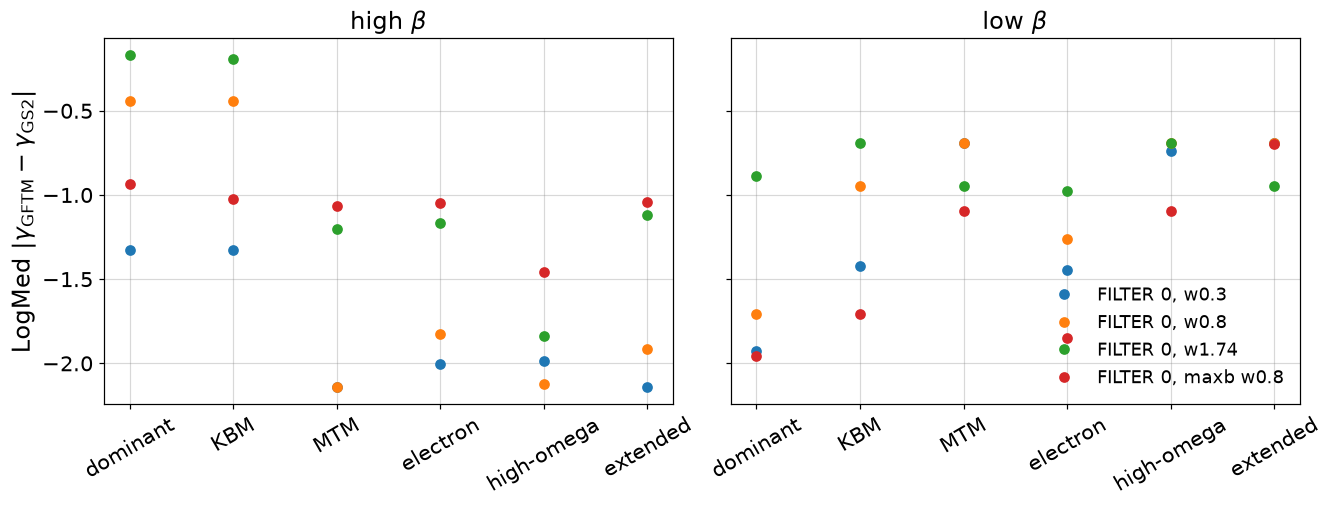

In [10]:
fig_rules, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
names = list(dict.fromkeys(rules_table.rule))
for ax, col, title in zip(axes, ("LogMed hi", "LogMed lo"), (r"high $\beta$", r"low $\beta$")):
    for n, lab in enumerate(spec_leaves):
        t = rules_table[rules_table.leaf == lab].set_index("rule").loc[names]
        ax.plot(range(len(names)), t[col], color=f"C{n}", ls="", marker="o", label=lab.replace("spec ", "FILTER 0, "))
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30)
    ax.set_title(title, fontsize=fs_title)
    ax.tick_params(labelsize=fs_tick)
axes[0].set_ylabel(r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$", fontsize=fs_label)
axes[1].legend(fontsize=fs_legend)
fig_rules.savefig(plot_dir / "R4_selection_rules.png", dpi=150, bbox_inches="tight")
plt.show()

## (4) Other databases: where else is GFTM badly wrong, and what do those cases share?
GFTM at WIDTH 0.4 and 0.8, dominant mode, against GS2 on every database with both:

| database | GS2 | GFTM (both FILTER 0.5 unless noted) |
|---|---|---|
| SPR-045, M1 (KBM hypercubes) | `LATIN_HYPERCUBE/<db>/kbm_8d`, γ from `pyro_cube_avg` | `wo_f05_w0p4000`, `wo_f05_w0p8000` (NBASIS 22 / NXGRID 28) |
| R4 hypercube | `LATIN_HYPERCUBE/R4/kbm_8d/pyro_cube` (no averaged cube) | `wo_w0p4000`, `wo_w0p8000` (**FILTER 0**; no FILTER 0.5 arm exists) |
| R3, R4, M1_A1_NE (β scans) | `scan_beta/<case>/parameter_scan_GS2` | `scan_beta_f05/<case>/w0p4`, `w0p8` |
| S1_3 q, ŝ scans | `scan_{q,shat}/S1_3/parameter_scan_GS2` | `scan_{q,shat}_f05/S1_3/w0p4`, `w0p8` |

**Bad** = `over` (GS2 γ > 0.01 and γ_GFTM > 3 γ_GS2) or `spurious` (GS2 γ ≤ 0.01 and γ_GFTM > 0.1).
**Good** = GS2 γ > 0.01 and γ_GFTM within ×1.5. Features per case: ky, β, α = q²(R/a)|β′| (β′ in pyro normalisation,
from each sample's own Pyro via `sample_pyro`), q, ŝ, GS2 class (cube classifier) and tolerance, GFTM's dominant ω, T,
φ extent, and ky·(|B∥|/|φ|)_GFTM (the ky-corrected B∥ share of `gftm_bpar_ratio`).

In [11]:
over_factor, good_factor, g_floor, spur_gamma = 3.0, 1.5, 0.01, 0.1
widths = (0.4, 0.8)
dbs = {   # name -> (kind, GS2 path, GS2 gamma cube or scan parameter, {WIDTH: GFTM path})
    "SPR-045": ("cube", "GS2/Runs/LATIN_HYPERCUBE/SPR-045/kbm_8d", "pyro_cube_avg",
                {w: f"GFTM/Runs/LATIN_HYPERCUBE/SPR-045/kbm_8d/wo_f05_w0p{int(w * 10)}000" for w in widths}),
    "M1": ("cube", "GS2/Runs/LATIN_HYPERCUBE/M1/kbm_8d", "pyro_cube_avg",
           {w: f"GFTM/Runs/LATIN_HYPERCUBE/M1/kbm_8d/wo_f05_w0p{int(w * 10)}000" for w in widths}),
    "R4 cube": ("cube", "GS2/Runs/LATIN_HYPERCUBE/R4/kbm_8d", "pyro_cube",
                {w: f"GFTM/Runs/LATIN_HYPERCUBE/R4/kbm_8d/wo_w0p{int(w * 10)}000" for w in widths}),
    **{c: ("scan", f"GS2/Runs/scan_beta/{c}/parameter_scan_GS2", "beta",
           {w: f"GFTM/Runs/scan_beta_f05/{c}/w0p{int(w * 10)}" for w in widths}) for c in ("R3", "R4", "M1_A1_NE")},
    **{f"S1_3 {p}": ("scan", f"GS2/Runs/scan_{p}/S1_3/parameter_scan_GS2", p,
                     {w: f"GFTM/Runs/scan_{p}_f05/S1_3/w0p{int(w * 10)}" for w in widths}) for p in ("q", "shat")},
}


def gk(path):
    "pyro gk output of a GFTM leaf (cube.nc or pyroscan.nc), with pyro Extent, dequantified"
    path = Path(path)
    nc = path / "pyro_cube" / "cube.nc" if (path / "pyro_cube" / "cube.nc").exists() else path / "pyroscan.nc"
    o = PyroScanGKOutput.from_netcdf(nc)
    Extent(o, fraction=fraction)
    out = o.data.pint.dequantify()
    return out.squeeze("kx", drop=True) if "kx" in out.dims else out


def peak_ratio(ef):
    "peak|B_par| / peak|phi| over theta of a (..., field, theta) eigenfunction array"
    a = np.abs(np.nan_to_num(ef))
    return a[..., 2, :].max(-1) / a[..., 0, :].max(-1)


def sample_features(scan, n):
    "ky, beta, q, shat and alpha of every sample, from the sample's own Pyro (scanned values and derived beta_prime applied)"
    rows = []
    for i in range(n):
        p = scan.sample_pyro(i)
        lg = p.local_geometry
        rows.append({"ky": float(p.numerics.ky.to(p.norms.pyrokinetics).m), "beta": float(p.numerics.beta.to(p.norms.pyrokinetics).m),
                     "q": float(lg.q.m), "shat": float(lg.shat.m),
                     "alpha": float(lg.q.m ** 2 * lg.Rmaj.m * abs(lg.beta_prime.to(p.norms.pyrokinetics).m))})
    return pd.DataFrame(rows)


def gs2_scan(kind, gs2_path):
    "(scan, final-time sample dataset, unstacked grid or None) of a GS2 cube or gridded scan"
    if kind == "cube":
        return *mc.load_gs2_cube(data_root / gs2_path, "pyro_cube"), None
    leaf = data_root / gs2_path
    scan = mc.attach_legacy_funcs(PyroScan(pyroscan_json=leaf / "pyroscan.json", load_base_pyro=True,
                                           base_directory=leaf, file_name="gs2.in"))
    grid = PyroScanGKOutput.from_netcdf(leaf / "pyroscan.nc").data
    return scan, mc.as_samples(scan, grid), grid


tables = []
for db, (kind, gs2_path, gref, gftm_paths) in dbs.items():
    scan, ds, grid = gs2_scan(kind, gs2_path)
    gs = ds if grid is not None else PyroScanGKOutput.from_netcdf(data_root / gs2_path / gref / "cube.nc").data
    names = ds.sample_name.values.astype(str)
    assert (gs.sample_name.values.astype(str) == names).all()
    n = len(names)
    label = np.asarray(mc.classify(mc.indicators(scan, ds)))
    base = pd.concat([pd.DataFrame({"db": db, "sample": names, "g_gs2": v(gs.growth_rate).ravel(),
                                    "tol_gs2": v(ds.growth_rate_tolerance).ravel(), "gs2_class": label}),
                      sample_features(scan, n)], axis=1)
    for wd, gp in gftm_paths.items():
        d = gk(data_root / gp)
        if grid is not None:   # GFTM's grid may hold extra ky: select GS2's, then stack in GS2's sample order
            d = mc.as_samples(scan, d.sel(ky=v(grid.ky), method="nearest"))
            assert np.allclose(v(d.ky), base.ky, rtol=1e-3), (db, wd, "ky differs from GS2")
        d = d.transpose("sample", "mode", ...)
        m = xr.DataArray(np.nan_to_num(v(d.growth_rate), nan=-np.inf).argmax(-1), dims="sample")
        dd = d.isel(mode=m)
        if "tearing_parameter" in d:
            T = v(dd.tearing_parameter)
        else:   # hypercube GFTM cubes store no T: FieldLine on each sample's own geometry, in the cube's own order
            T = v(mc.tearing_parity(mc.load_gftm_cube(data_root / gp)[0], dd)["T"]).ravel()
        dd = dd.assign(T=("sample", T))
        if grid is None:
            idx = pd.Index(dd.sample_name.values.astype(str)).get_indexer(names)
            assert (idx >= 0).all(), (db, wd, "GS2 samples missing from GFTM")
            dd = dd.isel(sample=idx)
        gd = v(dd.growth_rate)
        tables.append(base.assign(width=wd, g_gftm=np.where(np.isfinite(gd) & (gd > 0), gd, 0.0), w_gftm=v(dd.mode_frequency),
                                  T_gftm=v(dd["T"]), ext_gftm=v(dd.extent.sel(field="phi")),
                                  kyr_gftm=base.ky.values * peak_ratio(v(dd.eigenfunctions.transpose("sample", "field", "theta")))))
    print(db, "samples", n, "| GS2 gamma > 0.01:", int((base.g_gs2 > g_floor).sum()), "| classes", pd.Series(label).value_counts().to_dict())

D = pd.concat(tables, ignore_index=True)
ratio = D.g_gftm / D.g_gs2
D["cls"] = np.select([(D.g_gs2 > g_floor) & (ratio > over_factor), (D.g_gs2 <= g_floor) & (D.g_gftm > spur_gamma),
                      (D.g_gs2 > g_floor) & (ratio < good_factor) & (ratio > 1 / good_factor)],
                     ["over", "spurious", "good"], "other")
D["bad"] = D.cls.isin(["over", "spurious"])
print(D.groupby(["width", "db"], sort=False).cls.value_counts().unstack(fill_value=0).to_string())

SPR-045 samples 300 | GS2 gamma > 0.01: 164 | classes {'mixed': 175, 'KBM': 125}


M1 samples 300 | GS2 gamma > 0.01: 232 | classes {'KBM': 167, 'mixed': 113, 'MTM': 20}


R4 cube samples 500 | GS2 gamma > 0.01: 484 | classes {'KBM': 280, 'mixed': 220}


R3 samples 798 | GS2 gamma > 0.01: 668 | classes {'mixed': 341, 'MTM': 274, 'KBM': 183}


R4 samples 798 | GS2 gamma > 0.01: 283 | classes {'mixed': 404, 'MTM': 222, 'KBM': 172}


M1_A1_NE samples 760 | GS2 gamma > 0.01: 355 | classes {'mixed': 377, 'KBM': 361, 'MTM': 22}


S1_3 q samples 110 | GS2 gamma > 0.01: 68 | classes {'mixed': 46, 'KBM': 41, 'MTM': 23}


S1_3 shat samples 110 | GS2 gamma > 0.01: 90 | classes {'KBM': 46, 'MTM': 39, 'mixed': 25}
cls              other  good  over  spurious
width db                                    
0.4   SPR-045      177   120     3         0
      M1           102   162    21        15
      R4 cube      151   319    24         6
      R3           335   385    78         0
      R4           330   167    43       258
      M1_A1_NE     495   127    69        69
      S1_3 q        68    36     6         0
      S1_3 shat     40    64     6         0
0.8   SPR-045      154   119    12        15
      M1            78   157    38        27
      R4 cube      169   320    10         1
      R3           332   401    59         6
      R4           214   134   105       345
      M1_A1_NE     471   142    61        86
      S1_3 q        63    36     7         4
      S1_3 shat     44    47    15         4


### The common thread
Databases span different parameter ranges, so each feature is turned into its **percentile within its own database
and WIDTH** before pooling. A feature unrelated to badness puts the bad cases at a median percentile of 0.5. Shown for
all bad cases and for `over` and `spurious` separately; per-database medians are printed below.

median within-database percentile of each feature (0.5 = no signal); n: {(0.4, 'bad'): 598, (0.4, 'over'): 250, (0.4, 'spurious'): 348, (0.4, 'good'): 1380, (0.8, 'bad'): 795, (0.8, 'over'): 307, (0.8, 'spurious'): 488, (0.8, 'good'): 1356}
           0.4                        0.8                     
           bad  over spurious  good   bad  over spurious  good
ky        0.71  0.69     0.73  0.42  0.56  0.56     0.56  0.41
beta      0.55  0.43     0.66  0.42  0.61  0.55     0.66  0.42
alpha     0.55  0.45     0.66  0.43  0.61  0.55     0.66  0.44
q         0.62  0.62     0.65  0.54  0.54  0.55     0.52  0.55
shat      0.75  0.76     0.72  0.45  0.56  0.50     0.59  0.47
tol_gs2   0.65  0.58     0.69  0.29  0.62  0.53     0.66  0.27
w_gftm    0.29  0.44     0.25  0.49  0.50  0.50     0.31  0.52
T_gftm    0.72  0.68     0.74  0.36  0.61  0.60     0.63  0.44
ext_gftm  0.73  0.69     0.75  0.43  0.50  0.46     0.59  0.43
kyr_gftm  0.31  0.34     0.28  0.52  0.40  0.35     0.43  0.53


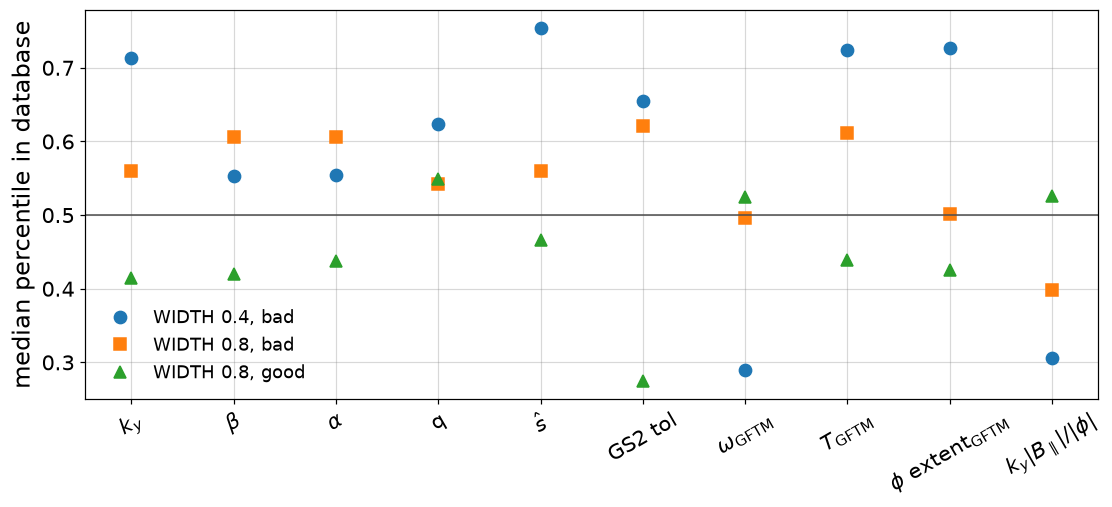

family           ion, ky<0.5  electron, ky>=0.5  ion, ky>=0.5  electron, ky<0.5
width db                                                                       
0.4   SPR-045              3                  0             0                 0
      M1                  11                 11            11                 3
      R4 cube             19                  5             1                 5
      R3                   0                 68             9                 1
      R4                  92                190            16                 3
      M1_A1_NE            41                  0            96                 1
      S1_3 q               0                  0             6                 0
      S1_3 shat            0                  0             6                 0
0.8   SPR-045             27                  0             0                 0
      M1                  15                 19            10                21
      R4 cube              2            

gs2_class        mixed  KBM  MTM
width db                        
0.4   SPR-045        1    2    0
      M1            23   12    1
      R4 cube       16   14    0
      R3            70    1    7
      R4           182   14  105
      M1_A1_NE      69   66    3
      S1_3 q         1    5    0
      S1_3 shat      0    4    2
0.8   SPR-045       17   10    0
      M1            35   26    4
      R4 cube        1   10    0
      R3            53    9    3
      R4           241   42  167
      M1_A1_NE      80   62    5
      S1_3 q         2    6    3
      S1_3 shat      4    4   11


In [12]:
features = ["ky", "beta", "alpha", "q", "shat", "tol_gs2", "w_gftm", "T_gftm", "ext_gftm", "kyr_gftm"]
feature_label = {"ky": r"$k_y$", "beta": r"$\beta$", "alpha": r"$\alpha$", "q": "q", "shat": r"$\hat{s}$",
                 "tol_gs2": "GS2 tol", "w_gftm": r"$\omega_{\rm GFTM}$", "T_gftm": r"$T_{\rm GFTM}$",
                 "ext_gftm": r"$\phi$ extent$_{\rm GFTM}$", "kyr_gftm": r"$k_y|B_\parallel|/|\phi|$"}
P = D.copy()
for f in features:   # NaN where the feature is constant within the database (q and shat on the beta scans)
    P[f] = D.groupby(["db", "width"])[f].transform(lambda x: x.rank(pct=True) if x.nunique() > 1 else np.nan)
thread = pd.DataFrame({(wd, c): P[(P.width == wd) & (P.cls.isin(["over", "spurious"]) if c == "bad" else P.cls == c)][features].median()
                       for wd in widths for c in ("bad", "over", "spurious", "good")})
print("median within-database percentile of each feature (0.5 = no signal); n:",
      {(wd, c): int(((P.width == wd) & (P.cls.isin(["over", "spurious"]) if c == "bad" else P.cls == c)).sum())
       for wd in widths for c in ("bad", "over", "spurious", "good")})
print(thread.round(2).to_string())

fig_thread, ax = plt.subplots(figsize=(10, 4.5))
for n, (wd, c) in enumerate([(0.4, "bad"), (0.8, "bad"), (0.8, "good")]):
    ax.plot(range(len(features)), thread[(wd, c)], ls="", marker="os^"[n], ms=8, color=f"C{n}", label=f"WIDTH {wd}, {c}")
ax.axhline(0.5, color="0.3", lw=1, marker="")
ax.set_xticks(range(len(features)))
ax.set_xticklabels([feature_label[f] for f in features], rotation=30)
ax.set_ylabel("median percentile in database", fontsize=fs_label)
ax.tick_params(labelsize=fs_tick)
ax.legend(fontsize=fs_legend)
fig_thread.savefig(plot_dir / "common_thread_percentiles.png", dpi=150, bbox_inches="tight")
plt.show()

with pd.option_context("display.width", 250):
    # two candidate families: GFTM's dominant mode in the ion (omega > 0) or electron direction, at low or high ky
    P["family"] = np.where(mc.ION_DIRECTION * D.w_gftm > 0, "ion", "electron") + np.where(D.ky >= 0.5, ", ky>=0.5", ", ky<0.5")
    print(P[P.bad].groupby(["width", "db"], sort=False).family.value_counts().unstack(fill_value=0).to_string())
    print(P[P.bad].groupby(["width", "family"]).agg(n=("ky", "size"), alpha_pct=("alpha", "median"), beta_pct=("beta", "median"),
                                                    g_gs2=("g_gs2", "median"), g_gftm=("g_gftm", "median"),
                                                    T_gftm=("T_gftm", "median"), ext_gftm=("ext_gftm", "median")).round(2).to_string())
    print(D[D.cls.isin(["over", "spurious", "good"])].groupby(["width", "db", "cls"], sort=False)[features].median().round(3).to_string())
    print(D[D.bad].groupby(["width", "db"], sort=False).gs2_class.value_counts().unstack(fill_value=0).to_string())

Δγ = γ_GFTM − γ_GS2 against α, per database, WIDTH 0.8 (WIDTH 0.4 in the second figure). Filled: bad. Hollow: the rest.

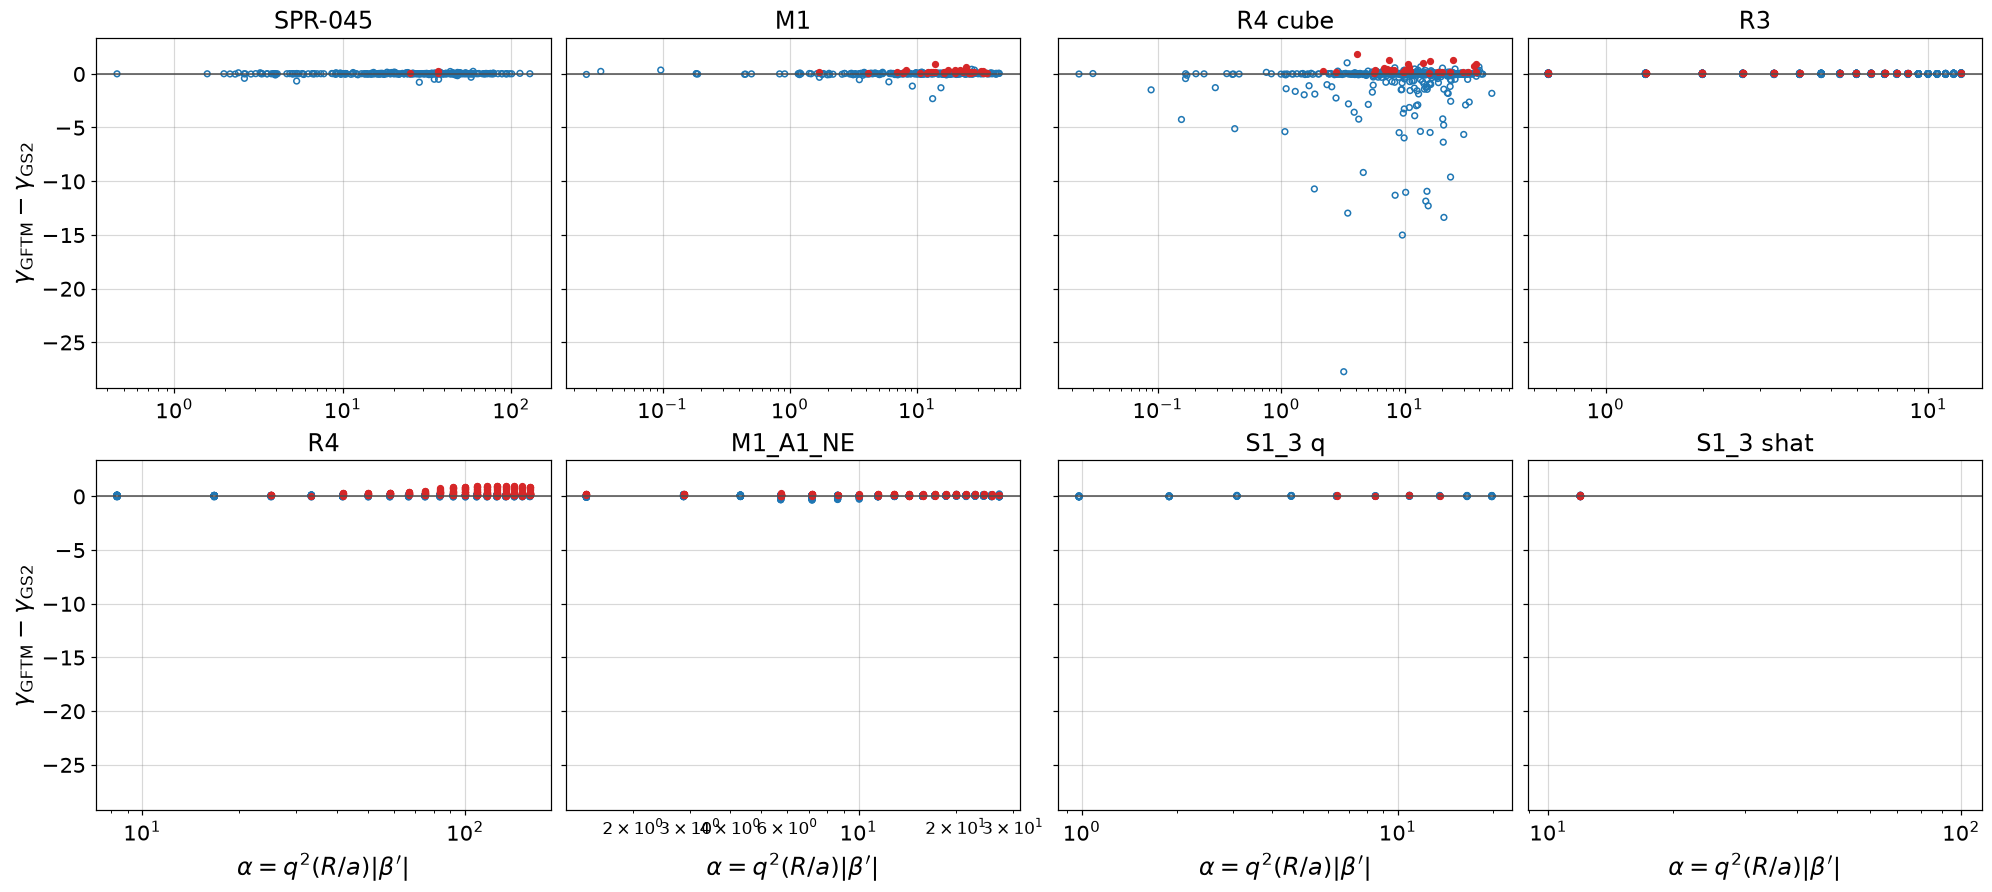

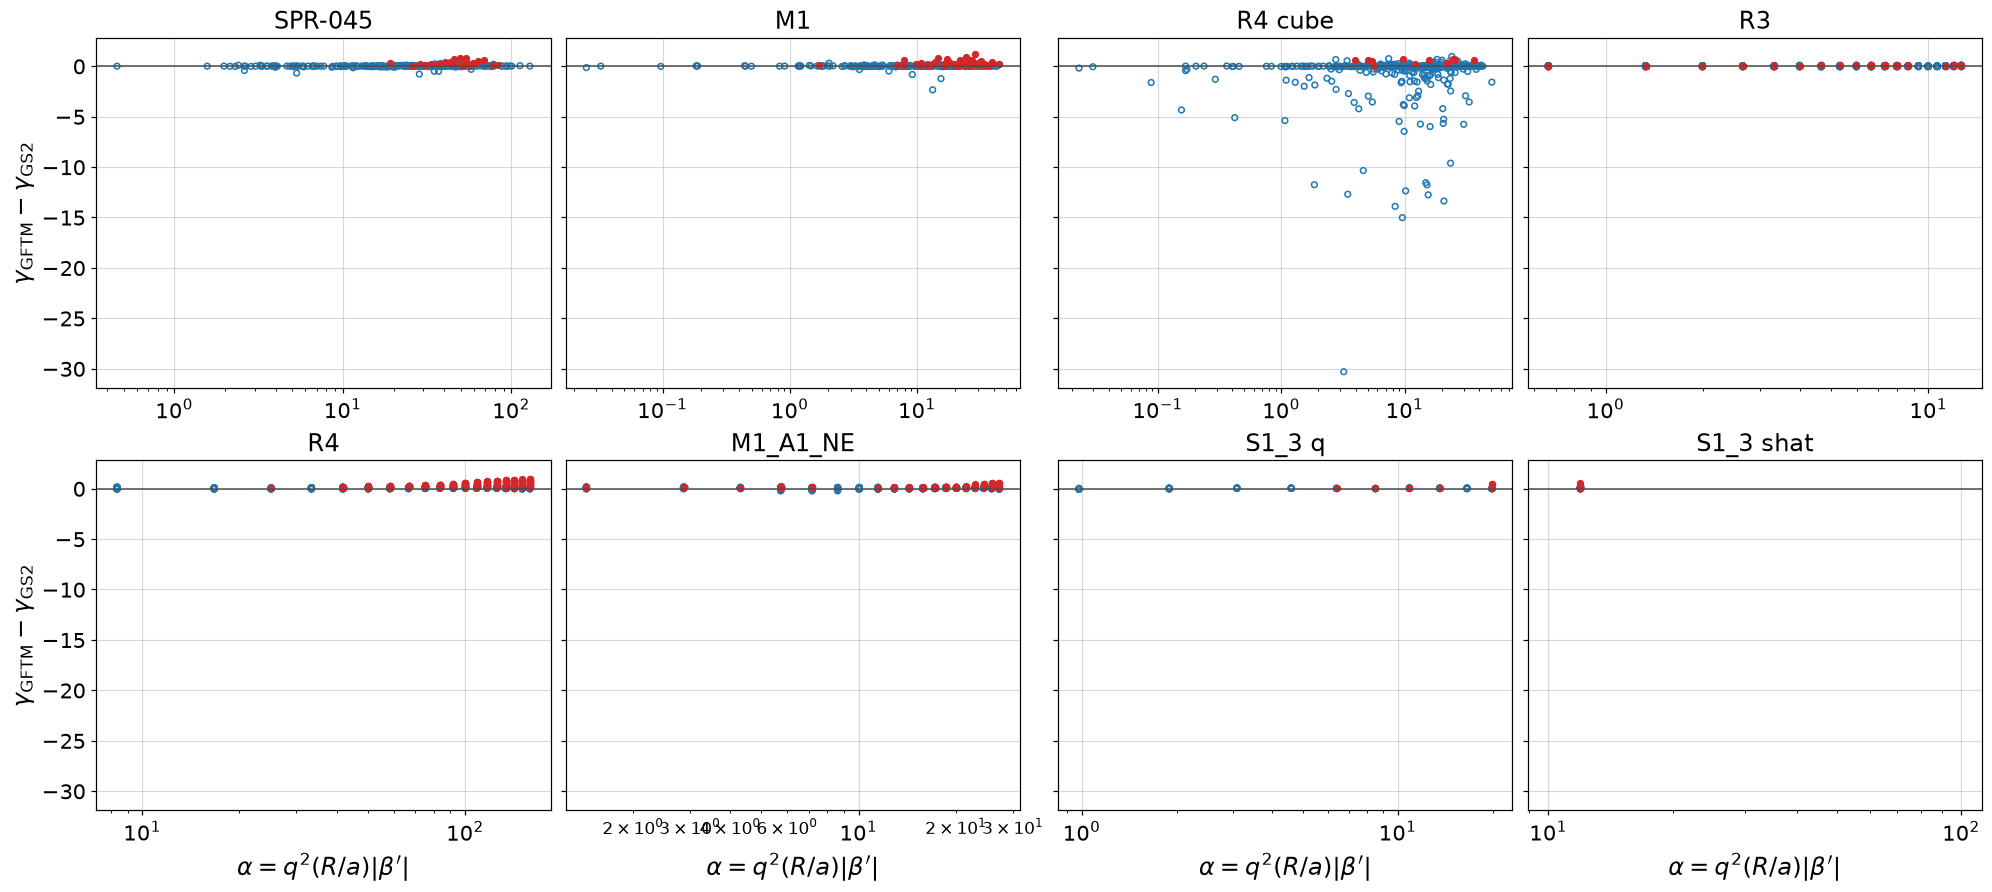

In [13]:
dbn = list(dbs)
figs_alpha = {}
for wd in widths:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
    for ax, db in zip(axes.flat, dbn):
        t = D[(D.db == db) & (D.width == wd)]
        for bad in (False, True):
            s = t[t.bad == bad]
            ax.scatter(s.alpha, s.g_gftm - s.g_gs2, s=14, edgecolors="C3" if bad else "C0", facecolors="C3" if bad else "none")
        ax.axhline(0, color="0.3", lw=1, marker="")
        ax.set_xscale("log")
        ax.set_title(db, fontsize=fs_title)
        ax.tick_params(labelsize=fs_tick)
    for ax in axes[-1]:
        ax.set_xlabel(r"$\alpha = q^2 (R/a) |\beta'|$", fontsize=fs_label)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\gamma_{\rm GFTM}-\gamma_{\rm GS2}$", fontsize=fs_label)
    fig.savefig(plot_dir / f"common_thread_dgamma_vs_alpha_w{wd:g}.png".replace("0.", "0p"), dpi=150, bbox_inches="tight")
    figs_alpha[wd] = fig
plt.show()

### Ideal-ballooning stability of a handful of bad and good cases
pyro `Diagnostics.ideal_ballooning_solver` at θ0 = 0 on each sample's own Pyro, nperiod 5 / ntheta 64 (as 38e9.9).
Only the sign means anything. Up to 3 worst bad (largest Δγ) and 3 good cases per database at WIDTH 0.8; the R4
β scan is already done (stable at every β, 38e9.9).

In [14]:
def ideal(pyro):
    pyro.numerics.nperiod, pyro.numerics.ntheta = 5, 64
    return float(Diagnostics(pyro).ideal_ballooning_solver(theta0=0.0))


ib = []
for db, (kind, gs2_path, gref, _) in dbs.items():
    if db == "R4":
        continue
    scan = gs2_scan(kind, gs2_path)[0]
    t = D[(D.db == db) & (D.width == 0.8)].reset_index(drop=True)
    picks = list(t[t.bad].assign(dg=t.g_gftm - t.g_gs2).nlargest(3, "dg").index) + list(t[t.cls == "good"].head(3).index)
    for k in picks:
        ib.append({"db": db, "sample": t.loc[k, "sample"], "cls": t.loc[k, "cls"], "alpha": t.loc[k, "alpha"],
                   "g_gs2": t.loc[k, "g_gs2"], "g_gftm": t.loc[k, "g_gftm"], "gamma_ideal": ideal(scan.sample_pyro(int(k)))})
ib = pd.DataFrame(ib)
print(ib.round(3).to_string(index=False))
print("ideal-unstable:", ib.groupby("cls").gamma_ideal.apply(lambda x: f"{(x > 0).sum()} of {len(x)}").to_dict())

       db             sample      cls  alpha  g_gs2  g_gftm  gamma_ideal
  SPR-045      iteration_148     over 49.309  0.039   0.870       -0.000
  SPR-045      iteration_158 spurious 53.570  0.001   0.817       -0.000
  SPR-045      iteration_243 spurious 53.356 -0.012   0.690       -0.000
  SPR-045        iteration_7     good 33.769  0.772   0.925        0.040
  SPR-045       iteration_12     good 12.286  0.136   0.118        0.023
  SPR-045       iteration_13     good  3.273  0.016   0.023       -0.000
       M1      iteration_169     over 28.307  0.191   1.417       -0.000
       M1      iteration_107 spurious 24.418 -0.054   0.860       -0.000
       M1      iteration_274     over 14.747  0.057   0.835       -0.001
       M1        iteration_0     good  0.448  0.414   0.400       -0.000
       M1        iteration_3     good 26.156  0.010   0.011       -0.000
       M1        iteration_5     good  8.208  0.128   0.137       -0.000
  R4 cube      iteration_469     over  9.765  0.196